# DAV 6150 Module 8 Assignment
## *Classification via KNN & SVM*

## Introduction 

In this assignment, we explore a comprehensive dataset on customer behavior within a large insurance company, sourced from Kaggle. The dataset comprises more than 14,000 observations detailing various customer characteristics and purchasing patterns. Here, our primary objective is to model and predict whether an existing customer is likely to purchase an additional insurance product using a series of logistic regression models.

To achieve this, we follow a complete data science lifecycle approach, which includes:

- **Loading the Dataset:** Importing the data into a Pandas DataFrame.
- **Exploratory Data Analysis (EDA):** Assessing data integrity by identifying issues such as missing values, outliers, and initial trends.
- **Data Preparation:** Applying necessary feature engineering, transformation, and feature selection techniques to isolate the most relevant predictors.
- **Prepped Data Review:** Re-evaluating the dataset after data preparation to ensure quality and suitability for modeling.
- **Regression Modeling:** Developing and comparing multiple logistic regression models using cross validation and various performance metrics.
- **Select Models:** Explaining our model selection criteria and identifying the preferred model. We will compare and contrast its performance with the other models, discuss why it was chosen, and apply it to the testing subset to evaluate whether it performed as expected.
- **Conclusions:** Summarizing our key findings and evaluating the overall model performance.

This structured approach will help us gain clear insights into customer behavior.

### 1. Load the data

#### A. Import Python Libraries

- Import all libraries that are required for our analysis, such as Data Loading, Statistical analysis, Visualization etc.

- __Pandas__ and __Numpy__ have been used for __Data Manipulation__ and __numerical Calculations__.

- __Matplotlib__ and __Seaborn__ have been used for __Data visualizations__.

- GitHub source link: https://raw.githubusercontent.com/Nikkat-Afrin/DAV-6150-1/refs/heads/main/M7_Data.csv

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import functools as _ft
if not getattr(sns, "_palette_hue_patch", False):
    for _f in ("countplot","barplot","boxplot","violinplot","stripplot","swarmplot","pointplot","boxenplot"):
        _o = getattr(sns, _f, None)
        if _o is None:
            continue
        def _w(*a, _o=_o, **k):
            if k.get("palette") is not None and "hue" not in k:
                if "x" in k:
                    k["hue"] = k["x"]
                elif "y" in k:
                    k["hue"] = k["y"]
                k.setdefault("legend", False)
            return _o(*a, **k)
        setattr(sns, _f, _ft.wraps(_o)(_w))
    sns._palette_hue_patch = True
#to ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
# load the data set
customer_data = pd.read_csv("data/M7_Data.csv")
customer_data

,TARGET,loyalty,ID,age,city,LOR,prod_A,type_A,type_B,prod_B,turnover_A,turnover_B,contract,age_P,lor_M
0,Y,99,77,66,2,0,0,0,0,0,333.561114,264.721010,2,66,3
1,Y,1,159,45,2,3,1,3,3,1,394.735699,284.904978,2,45,39
2,Y,1,220,42,2,2,1,3,6,1,342.180990,1175.589721,2,42,27
3,Y,99,303,31,2,0,0,0,0,0,453.757916,242.341754,2,31,3
4,Y,99,306,62,2,0,0,0,0,0,384.577469,287.008370,2,62,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14011,Y,99,151601,30,2,0,0,0,0,0,386.434278,284.309508,2,30,3
14012,Y,1,151634,27,2,2,1,3,3,1,376.842591,266.993794,2,27,27
14013,Y,99,151679,26,2,0,0,0,0,0,434.805703,284.629361,2,26,3
14014,Y,1,151804,75,2,1,1,3,3,1,366.273857,270.573265,2,75,15


### 2. Analyzing the data

In [3]:
customer_data.shape

(14016, 15)

There are **14016** observations and **15** variables in our dataset.

In [4]:
customer_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14016 entries, 0 to 14015
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   TARGET      14016 non-null  object 
 1   loyalty     14016 non-null  int64  
 2   ID          14016 non-null  int64  
 3   age         14016 non-null  int64  
 4   city        14016 non-null  int64  
 5   LOR         14016 non-null  int64  
 6   prod_A      14016 non-null  int64  
 7   type_A      14016 non-null  int64  
 8   type_B      14016 non-null  int64  
 9   prod_B      14016 non-null  int64  
 10  turnover_A  14016 non-null  float64
 11  turnover_B  14016 non-null  float64
 12  contract    14016 non-null  int64  
 13  age_P       14016 non-null  int64  
 14  lor_M       14016 non-null  int64  
dtypes: float64(2), int64(12), object(1)
memory usage: 1.6+ MB


#### Variable Types 

- **Categorical Variables**  
  - `TARGET`: Currently `object` (should be boolean for modeling).  
  - `loyalty`: Currently `int64`, but represents categories (0–3, 99).  
  - `city`: Currently `int64`, but each code is a distinct city.  
  - `prod_A` / `prod_B`: Currently `int64`, but represent binary categories (0/1).  
  - `type_A` / `type_B`: Currently `float64`, but should be categorical codes.  
  - `contract`: Currently `object`, which aligns with categorical text data.

- **Numerical Variables**  
  - `age`, `age_p`, `LOR`, `LOR_m`, `turnover_A`, `turnover_B`: All stored as numeric (`int64` or `float64`), which is appropriate.

**Changes to Consider:**  
- Convert `TARGET` from `object` to a numeric or boolean type.  
- Convert `type_A` and `type_B` from `float64` to categorical codes.  
- Convert `loyalty`, `city`, `prod_A`, and `prod_B` as categorical.


#### Type Conversion:

In [5]:
# Convert TARGET values from 'Y'/'N' to 1/0
customer_data['TARGET'] = customer_data['TARGET'].map({'Y': 1, 'N': 0})

# Convert type_A and type_B from float64 to categorical type
customer_data['type_A'] = customer_data['type_A'].astype('category')
customer_data['type_B'] = customer_data['type_B'].astype('category')

# Optionally, convert loyalty, city, prod_A, and prod_B to categorical
customer_data['loyalty'] = customer_data['loyalty'].astype('category')
customer_data['city'] = customer_data['city'].astype('category')
customer_data['prod_A'] = customer_data['prod_A'].astype('category')
customer_data['prod_B'] = customer_data['prod_B'].astype('category')


In [6]:
customer_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14016 entries, 0 to 14015
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   TARGET      14016 non-null  int64   
 1   loyalty     14016 non-null  category
 2   ID          14016 non-null  int64   
 3   age         14016 non-null  int64   
 4   city        14016 non-null  category
 5   LOR         14016 non-null  int64   
 6   prod_A      14016 non-null  category
 7   type_A      14016 non-null  category
 8   type_B      14016 non-null  category
 9   prod_B      14016 non-null  category
 10  turnover_A  14016 non-null  float64 
 11  turnover_B  14016 non-null  float64 
 12  contract    14016 non-null  int64   
 13  age_P       14016 non-null  int64   
 14  lor_M       14016 non-null  int64   
dtypes: category(6), float64(2), int64(7)
memory usage: 1.0 MB


After implementing the type conversion to our desired variables we can move forward with our analysis.

#### Null Values:

In [7]:
customer_data.isnull().sum()

TARGET        0
loyalty       0
ID            0
age           0
city          0
LOR           0
prod_A        0
type_A        0
type_B        0
prod_B        0
turnover_A    0
turnover_B    0
contract      0
age_P         0
lor_M         0
dtype: int64

By using the **isnull().sum()** function we got to know that there are no more null values in the data set. So, lets move forward and try to find out if there are any duplicate values in the dataset. 

#### Duplicate Values:

In [8]:
customer_data.nunique()

TARGET            2
loyalty           5
ID            11008
age              86
city             65
LOR               7
prod_A            2
type_A            3
type_B            4
prod_B            2
turnover_A    11008
turnover_B    11008
contract          1
age_P            86
lor_M             7
dtype: int64

In this we can observe that there are **11008** unique IDs where as we have total **14016** Observations in the dataset, so it looks like there are duplicate values in the data set, Lets try to delete the duplicate rows.

In [9]:
# view the actual duplicate rows (excluding the first occurrence)
duplicate_rows = customer_data[customer_data.duplicated()]
print("\nDuplicate row details:")
print(duplicate_rows)


Duplicate row details:
       TARGET loyalty      ID  age city  LOR prod_A type_A type_B prod_B  \
11008       1      99      77   66    2    0      0      0      0      0   
11009       1       1     159   45    2    3      1      3      3      1   
11010       1       1     220   42    2    2      1      3      6      1   
11011       1      99     303   31    2    0      0      0      0      0   
11012       1      99     306   62    2    0      0      0      0      0   
...       ...     ...     ...  ...  ...  ...    ...    ...    ...    ...   
14011       1      99  151601   30    2    0      0      0      0      0   
14012       1       1  151634   27    2    2      1      3      3      1   
14013       1      99  151679   26    2    0      0      0      0      0   
14014       1       1  151804   75    2    1      1      3      3      1   
14015       1      99  151811   61    2    0      0      0      0      0   

       turnover_A   turnover_B  contract  age_P  lor_M  
11008 

Here we can see that **3008** rows are duplicate and above **11008** are unique values of the IDs, If we sum the unique Ids and the duplicate rows **11008+3008 = 14016** rows, that is equal to total number of observations in our initial Dataset.

In [10]:
# Drop duplicate rows from the DataFrame
customer_data.drop_duplicates(inplace=True)

In [11]:
# view the actual duplicate rows (excluding the first occurrence)
duplicate_rows2 = customer_data[customer_data.duplicated()]
print("\nDuplicate row details:")
print(duplicate_rows2)


Duplicate row details:
Empty DataFrame
Columns: [TARGET, loyalty, ID, age, city, LOR, prod_A, type_A, type_B, prod_B, turnover_A, turnover_B, contract, age_P, lor_M]
Index: []


After Dropping the duplicate rows we can see that there are no more duplicate rows in the dataset.

### Dropping ID column:

We are dropping the Id column as it is not useful to us going forward in the prediction analysis.

In [12]:
customer_data.drop('ID', axis=1, inplace=True)

In [13]:
customer_data.columns

Index(['TARGET', 'loyalty', 'age', 'city', 'LOR', 'prod_A', 'type_A', 'type_B',
       'prod_B', 'turnover_A', 'turnover_B', 'contract', 'age_P', 'lor_M'],
      dtype='object')

## Exploratory Data Analysis  

### Univariate Analysis of Numerical Variable:

#### 1. age

Summary statistics for 'age':
count    11008.000000
mean        34.845203
std         13.032781
min          5.000000
25%         24.000000
50%         31.000000
75%         42.000000
max        102.000000
Name: age, dtype: float64


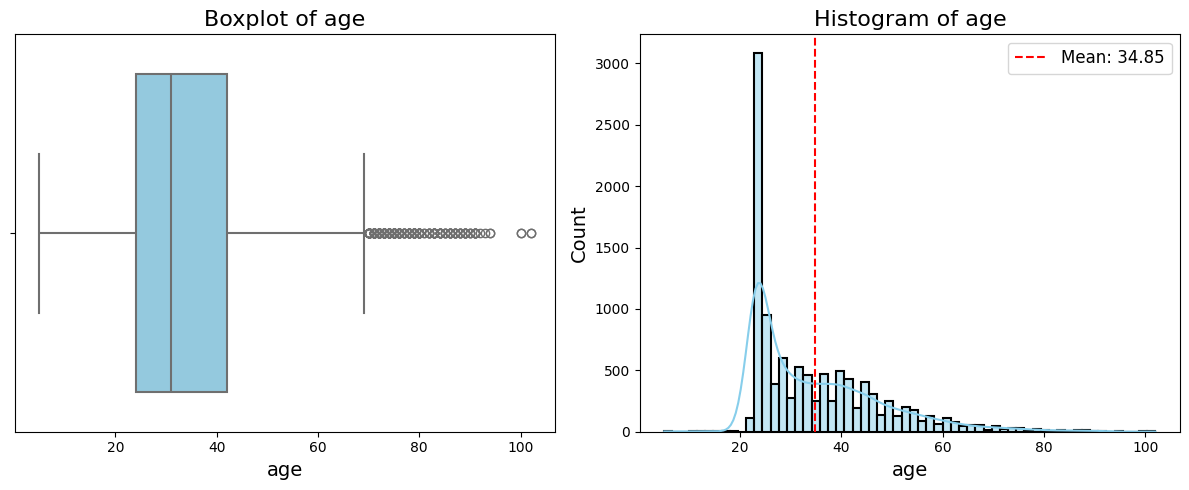

In [14]:
# Summary statistics for 'age'
print("Summary statistics for 'age':")
print(customer_data['age'].describe())

# Plotting: Boxplot and Histogram with KDE for 'age'
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Boxplot
sns.boxplot(x='age', data=customer_data, ax=ax[0], color='skyblue', linewidth=1.5)
ax[0].set_title('Boxplot of age', fontsize=16)
ax[0].set_xlabel('age', fontsize=14)

# Histogram with KDE
sns.histplot(customer_data['age'], kde=True, ax=ax[1], color='skyblue', linewidth=1.5)
ax[1].set_title('Histogram of age', fontsize=16)
ax[1].set_xlabel('age', fontsize=14)
ax[1].set_ylabel('Count', fontsize=14)

# Add mean line
mean_val = np.nanmean(customer_data['age'])
ax[1].axvline(x=mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
ax[1].legend(fontsize=12)

plt.tight_layout()
plt.show()


#### Univariate Analysis of `age`

- **Summary Statistics:**  
  - Mean age is approximately 34.85 years.  
  - Minimum age is 5(Can also be an outlier as customer cannot be a kid), and maximum age is 102(Can be a potential outlier).  
  - The standard deviation is about 13.03, indicating moderate spread.  
  - The median age is 31, with the 25th percentile at 24 and the 75th at 42.

- **Boxplot:**  
  - Shows a few outliers at higher ages (above 60), suggesting a small number of older individuals in the dataset.

- **Histogram + KDE:**  
  - The distribution is right-skewed, meaning the majority of individuals are on the younger side, with a tail extending into older ages.  
  - The mean (red dashed line) aligns slightly above 35, which is consistent with the histogram’s main cluster around the early to mid 30s.


#### 2. Age of partner in years 

Summary statistics for 'Age of partner':
count    11008.000000
mean        34.845203
std         13.032781
min          5.000000
25%         24.000000
50%         31.000000
75%         42.000000
max        102.000000
Name: age_P, dtype: float64


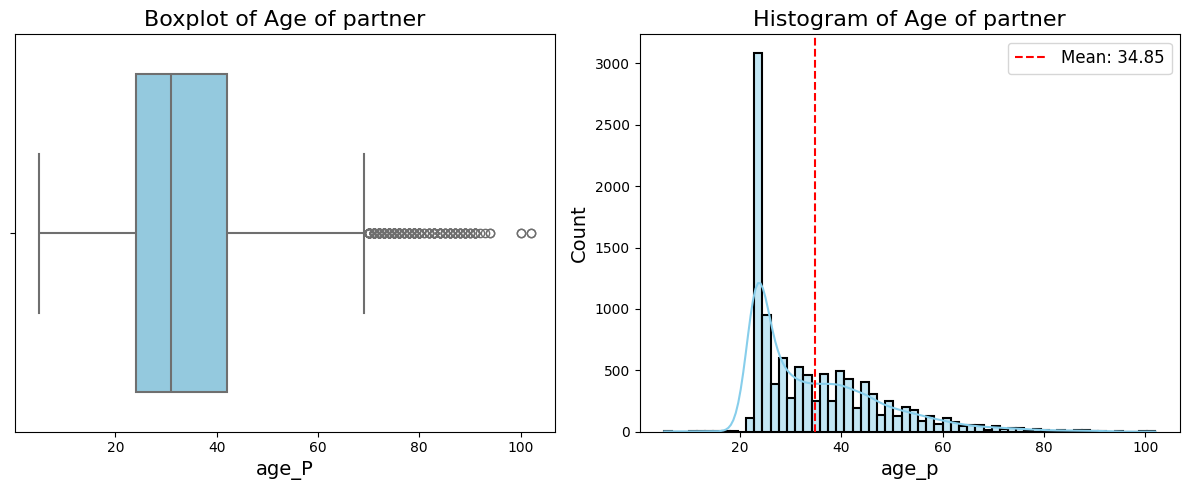

In [15]:
# Summary statistics for 'age_p'
print("Summary statistics for 'Age of partner':")
print(customer_data['age_P'].describe())

# Plotting: Boxplot and Histogram with KDE for 'age_p'
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Boxplot
sns.boxplot(x='age_P', data=customer_data, ax=ax[0], color='skyblue', linewidth=1.5)
ax[0].set_title('Boxplot of Age of partner', fontsize=16)
ax[0].set_xlabel('age_P', fontsize=14)

# Histogram with KDE
sns.histplot(customer_data['age_P'], kde=True, ax=ax[1], color='skyblue', linewidth=1.5)
ax[1].set_title('Histogram of Age of partner', fontsize=16)
ax[1].set_xlabel('age_p', fontsize=14)
ax[1].set_ylabel('Count', fontsize=14)

# Add mean line
mean_val = np.nanmean(customer_data['age_P'])
ax[1].axvline(x=mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
ax[1].legend(fontsize=12)

plt.tight_layout()
plt.show()


#### Univariate Analysis of `age_p` (Age of Partner)

- **Summary Statistics:**  
  - Mean age of partners is around 34.84 years.  
  - Minimum age is 5, and maximum age is 102.  
  - Standard deviation is approximately 13.03, suggesting a moderate spread.  
  - The median is 32, with the 25th percentile at 24 and the 75th percentile at 42.

- **Boxplot:**  
  - Reveals several outliers at the higher age range, indicating a small subset of older partners.

- **Histogram + KDE:**  
  - The distribution appears right-skewed, with a concentration of ages in the 20–40 range.  
  - The mean (red dashed line) is around 35, consistent with the main peak seen in the histogram.

**Note:** The metrics and distribution for `age_p` are nearly identical to those for `age`, suggesting the two columns may contain very similar data.


#### 3. Length of relationship in years

Summary statistics for 'Length of relationship in years':
count    11008.000000
mean         0.982649
std          0.939415
min          0.000000
25%          0.000000
50%          1.000000
75%          1.000000
max          6.000000
Name: LOR, dtype: float64


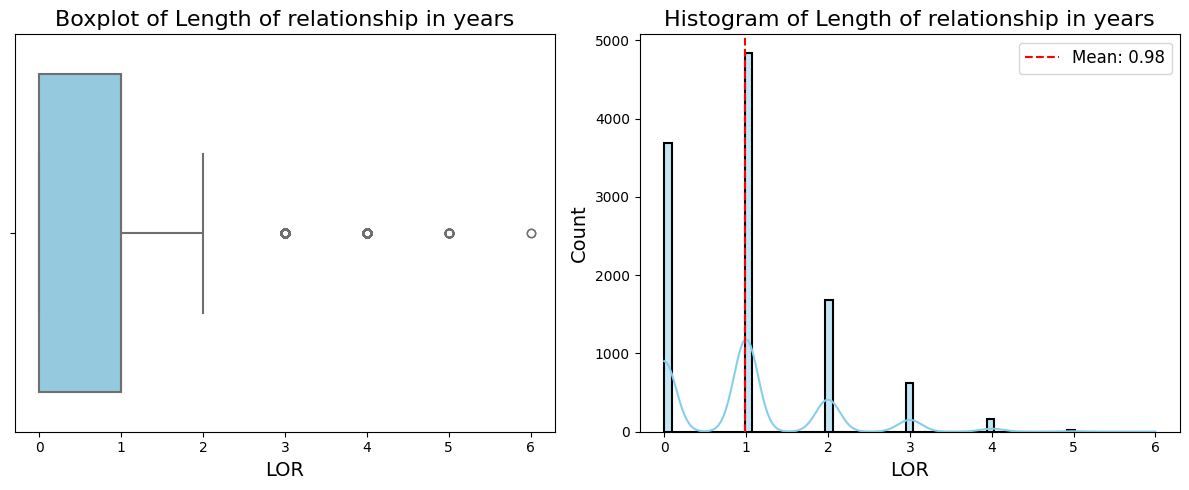

In [16]:
# Summary statistics for 'LOR'
print("Summary statistics for 'Length of relationship in years':")
print(customer_data['LOR'].describe())

# Plotting: Boxplot and Histogram with KDE for 'LOR'
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Boxplot
sns.boxplot(x='LOR', data=customer_data, ax=ax[0], color='skyblue', linewidth=1.5)
ax[0].set_title('Boxplot of Length of relationship in years', fontsize=16)
ax[0].set_xlabel('LOR', fontsize=14)

# Histogram with KDE
sns.histplot(customer_data['LOR'], kde=True, ax=ax[1], color='skyblue', linewidth=1.5)
ax[1].set_title('Histogram of Length of relationship in years', fontsize=16)
ax[1].set_xlabel('LOR', fontsize=14)
ax[1].set_ylabel('Count', fontsize=14)

# Add mean line
mean_val = np.nanmean(customer_data['LOR'])
ax[1].axvline(x=mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
ax[1].legend(fontsize=12)

plt.tight_layout()
plt.show()


#### Univariate Analysis of `LOR` (Length of Relationship in Years)

- **Summary Statistics:**  
  - Mean is about 0.98 years, indicating that on average, customers have been with the company for just under one year.  
  - The minimum is 0 and the maximum is 6 years, with a standard deviation of about 0.93.  
  - The median is 1, and the 25th and 75th percentiles are 0 and 1, respectively.

- **Boxplot:**  
  - The data is fairly concentrated at the lower end (0–1 years), with a few observations reaching up to 6 years.

- **Histogram + KDE:**  
  - The distribution is skewed, with clear peaks around 0, 1, and 2 years.  
  - The mean (red dashed line) near 1 year aligns with the bulk of the data being under 2 years.

Overall, this suggests most customers have relatively short relationships (under 2 years) with the company, with fewer customers having 3–5 years of relationship tenure.


#### 4. Length of relationship in months

Summary statistics for 'Length of relationship in months':
count    11008.000000
mean        14.791788
std         11.272981
min          3.000000
25%          3.000000
50%         15.000000
75%         15.000000
max         75.000000
Name: lor_M, dtype: float64


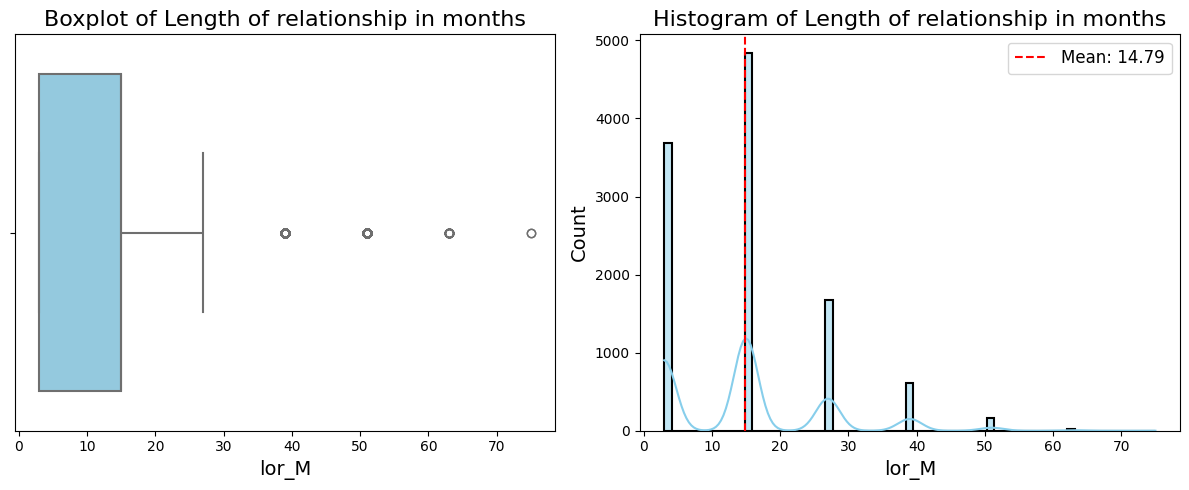

In [17]:
# Summary statistics for 'LOR_m'
print("Summary statistics for 'Length of relationship in months':")
print(customer_data['lor_M'].describe())

# Plotting: Boxplot and Histogram with KDE for 'LOR_m'
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Boxplot
sns.boxplot(x='lor_M', data=customer_data, ax=ax[0], color='skyblue', linewidth=1.5)
ax[0].set_title('Boxplot of Length of relationship in months', fontsize=16)
ax[0].set_xlabel('lor_M', fontsize=14)

# Histogram with KDE
sns.histplot(customer_data['lor_M'], kde=True, ax=ax[1], color='skyblue', linewidth=1.5)
ax[1].set_title('Histogram of Length of relationship in months', fontsize=16)
ax[1].set_xlabel('lor_M', fontsize=14)
ax[1].set_ylabel('Count', fontsize=14)

# Add mean line
mean_val = np.nanmean(customer_data['lor_M'])
ax[1].axvline(x=mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
ax[1].legend(fontsize=12)

plt.tight_layout()
plt.show()


#### Univariate Analysis of `LOR_m` (Length of Relationship in Months)

- **Summary Statistics:**  
  - Mean is about 14.79 months, indicating customers have been with the company for just over a year on average.  
  - Median is 15 months, with a minimum of 3 months and a maximum of 75 months.  
  - Standard deviation is around 11.28, suggesting a moderate spread.  
  - The 25th percentile is 3 months, and the 75th percentile is 15 months.

- **Boxplot:**  
  - Most values lie below 20 months, with a few outliers extending up to 60 months.  

- **Histogram + KDE:**  
  - The distribution shows a peak around 12 months, with a right-skewed tail toward higher values.  
  - The mean (red dashed line) near 15 months aligns with the majority of observations falling under 20 months.

Overall, this indicates that most customers maintain a relationship with the company for under two years, with fewer customers having much longer tenures. 
**Note** : Both the Lor and Lor_M give us the same information but on different scale i.e. in years and in months but the outcome is same.

#### 5. Turnover_A : Amount of money spent on Product A

Summary statistics for 'turnover_A':
count    11008.000000
mean       372.332403
std         96.685932
min        300.095909
25%        332.229899
50%        361.930298
75%        391.567662
max       5568.784139
Name: turnover_A, dtype: float64


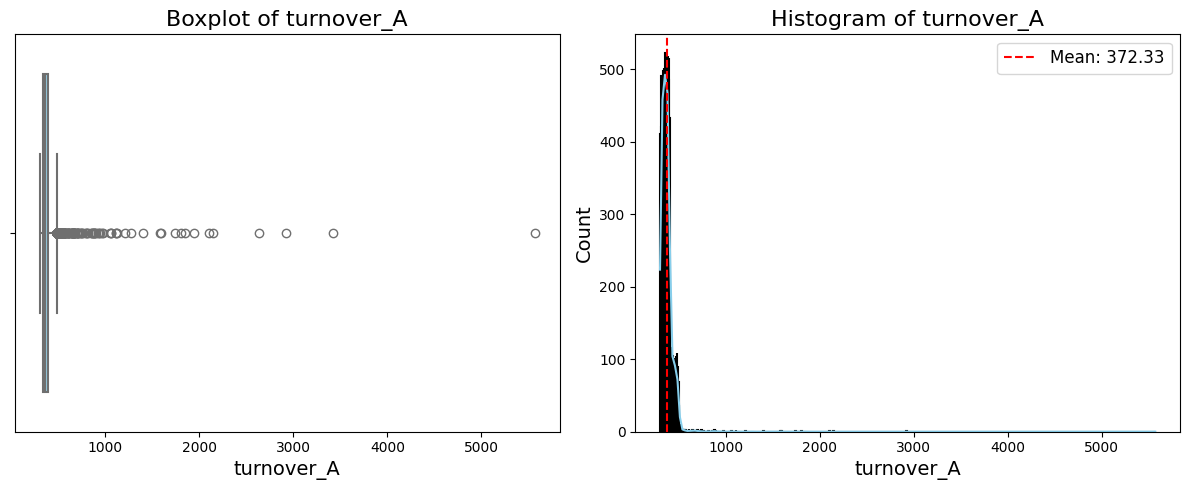

In [18]:
# Summary statistics for 'turnover_A'
print("Summary statistics for 'turnover_A':")
print(customer_data['turnover_A'].describe())

# Plotting: Boxplot and Histogram with KDE for 'turnover_A'
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Boxplot
sns.boxplot(x='turnover_A', data=customer_data, ax=ax[0], color='skyblue', linewidth=1.5)
ax[0].set_title('Boxplot of turnover_A', fontsize=16)
ax[0].set_xlabel('turnover_A', fontsize=14)

# Histogram with KDE
sns.histplot(customer_data['turnover_A'], kde=True, ax=ax[1], color='skyblue', linewidth=1.5)
ax[1].set_title('Histogram of turnover_A', fontsize=16)
ax[1].set_xlabel('turnover_A', fontsize=14)
ax[1].set_ylabel('Count', fontsize=14)

# Add mean line
mean_val = np.nanmean(customer_data['turnover_A'])
ax[1].axvline(x=mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
ax[1].legend(fontsize=12)

plt.tight_layout()
plt.show()


#### Univariate Analysis of `turnover_A`

- **Summary Statistics:**  
  - Mean turnover is about 372.33, with a median of 361.93.  
  - The distribution is quite spread out (std ≈ 96.65), with a minimum of 300 and a maximum of 5568.78.  
  - The 25th percentile is around 332.28, and the 75th is near 391.56.

- **Boxplot:**  
  - The boxplot reveals a concentration of values around 300–400, with several high-value outliers extending beyond 1000.

- **Histogram + KDE:**  
  - The distribution is heavily right-skewed, with most observations clustering in the lower range.  
  - The mean (red dashed line) around 372 falls near the main cluster, but the long tail indicates a few customers spending significantly more.


#### 6. Turnover_B : Amount of money spent on Product B

Summary statistics for 'turnover_B':
count    11008.000000
mean       344.120565
std        524.372413
min        191.962852
25%        218.302029
50%        235.025216
75%        253.759401
max      12249.084770
Name: turnover_B, dtype: float64


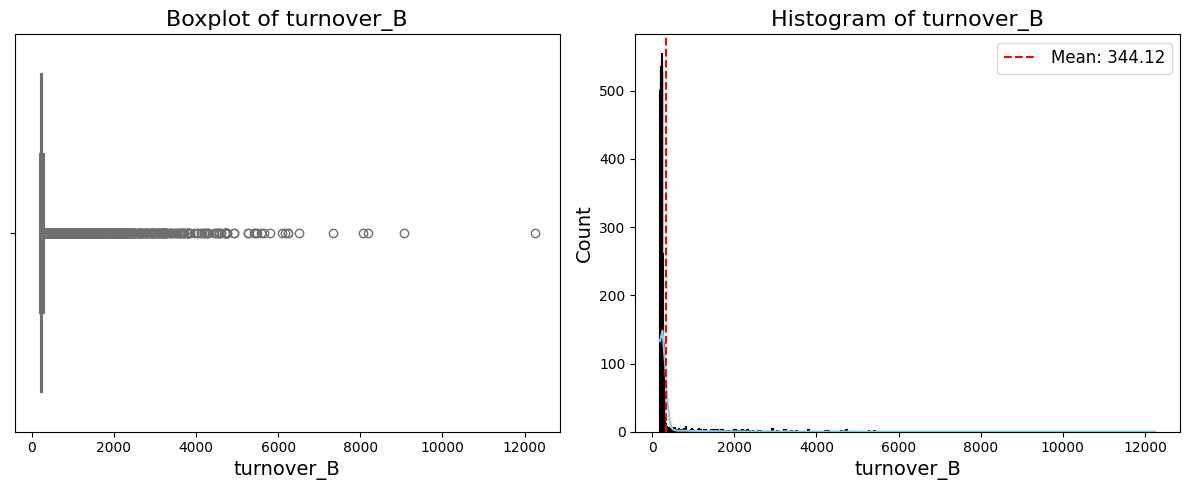

In [19]:
# Summary statistics for 'turnover_B'
print("Summary statistics for 'turnover_B':")
print(customer_data['turnover_B'].describe())

# Plotting: Boxplot and Histogram with KDE for 'turnover_B'
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Boxplot
sns.boxplot(x='turnover_B', data=customer_data, ax=ax[0], color='skyblue', linewidth=1.5)
ax[0].set_title('Boxplot of turnover_B', fontsize=16)
ax[0].set_xlabel('turnover_B', fontsize=14)

# Histogram with KDE
sns.histplot(customer_data['turnover_B'], kde=True, ax=ax[1], color='skyblue', linewidth=1.5)
ax[1].set_title('Histogram of turnover_B', fontsize=16)
ax[1].set_xlabel('turnover_B', fontsize=14)
ax[1].set_ylabel('Count', fontsize=14)

# Add mean line
mean_val = np.nanmean(customer_data['turnover_B'])
ax[1].axvline(x=mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
ax[1].legend(fontsize=12)

plt.tight_layout()
plt.show()


#### Univariate Analysis of `turnover_B`

- **Summary Statistics:**  
  - Mean turnover is approximately 344.12, with a median of 235.02.  
  - Standard deviation is around 524.37, indicating a wide spread.  
  - Minimum value is about 191.96, and the maximum reaches 12249.08.  
  - The 25th percentile is 218.30, and the 75th percentile is 253.75.

- **Boxplot:**  
  - Most values cluster around 200–400, with a many outliers extending beyond 1000.

- **Histogram + KDE:**  
  - The distribution is right-skewed, with the majority of observations in the lower range and a tail extending into higher turnover values.  
  - The mean (red dashed line) around 344 aligns with the main cluster, but some customers spend significantly more. 


### Univariate Analysis of Categorical Variable:

#### 1. Target

Value counts for 'TARGET':
TARGET
0    8000
1    3008
Name: count, dtype: int64
Number of unique categories: 2
--------------------------------------------------


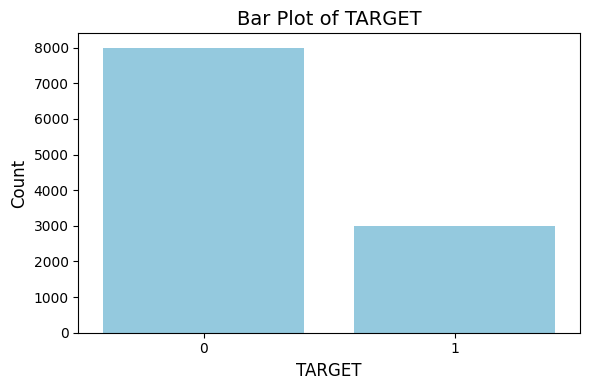

In [20]:
# Value counts for 'TARGET'
print("Value counts for 'TARGET':")
print(customer_data['TARGET'].value_counts(dropna=False))
print("Number of unique categories:", customer_data['TARGET'].nunique())
print("-" * 50)

# Bar plot
plt.figure(figsize=(6, 4))
sns.countplot(data=customer_data, x='TARGET', color='skyblue')
plt.title("Bar Plot of TARGET", fontsize=14)
plt.xlabel("TARGET", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.tight_layout()
plt.show()


#### Univariate Analysis of `TARGET`

- **Value Counts:**  
  - `0`: 8000 (did not purchase the new product)  
  - `1`: 3008 (purchased the new product)  

- **Observation:**  
  - The majority of customers (8000) did not buy the new product, while 3008 did.  
  - This imbalance indicates that there are more non-purchasers than purchasers in the dataset.


#### 2. loyalty

Value counts for 'loyalty':
loyalty
99    5048
3     2701
1     2019
2     1184
0       56
Name: count, dtype: int64
Number of unique categories: 5
--------------------------------------------------


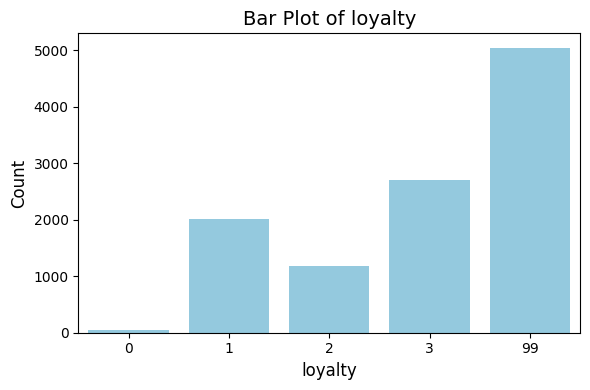

In [21]:
# Value counts for 'loyalty'
print("Value counts for 'loyalty':")
print(customer_data['loyalty'].value_counts(dropna=False))
print("Number of unique categories:", customer_data['loyalty'].nunique())
print("-" * 50)

# Bar plot
plt.figure(figsize=(6, 4))
sns.countplot(data=customer_data, x='loyalty', color='skyblue')
plt.title("Bar Plot of loyalty", fontsize=14)
plt.xlabel("loyalty", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.tight_layout()
plt.show()


#### Univariate Analysis of `loyalty`

- **Value Counts:**  
  - `99` (unclassified): 5048  
  - `3` (high loyalty): 2701  
  - `2`: 1184  
  - `1`: 521  
  - `0` (low loyalty): 26  

- **Observation:**  
  - The largest group is the unclassified category (`99`), followed by the highest loyalty level (`3`).  
  - Very few customers fall into the lowest loyalty level (`0`).  
  - The high number of unclassified entries (5048) suggests that this category may need special attention or reclassification for modeling purposes.


#### 3. City

In [22]:
customer_data['city'].unique()
# Value counts for 'city'
print("Value counts for 'city':")
print(customer_data['city'].value_counts(dropna=False))
print("Number of unique categories:", customer_data['city'].nunique())
print("-" * 50)


Value counts for 'city':
city
2      10769
0         20
8         17
1         17
9         16
       ...  
104        1
107        1
110        1
111        1
235        1
Name: count, Length: 65, dtype: int64
Number of unique categories: 65
--------------------------------------------------


Value counts for 'city':
city
2      10769
0         20
8         17
1         17
9         16
       ...  
104        1
107        1
110        1
111        1
235        1
Name: count, Length: 65, dtype: int64
Number of unique categories: 65
--------------------------------------------------


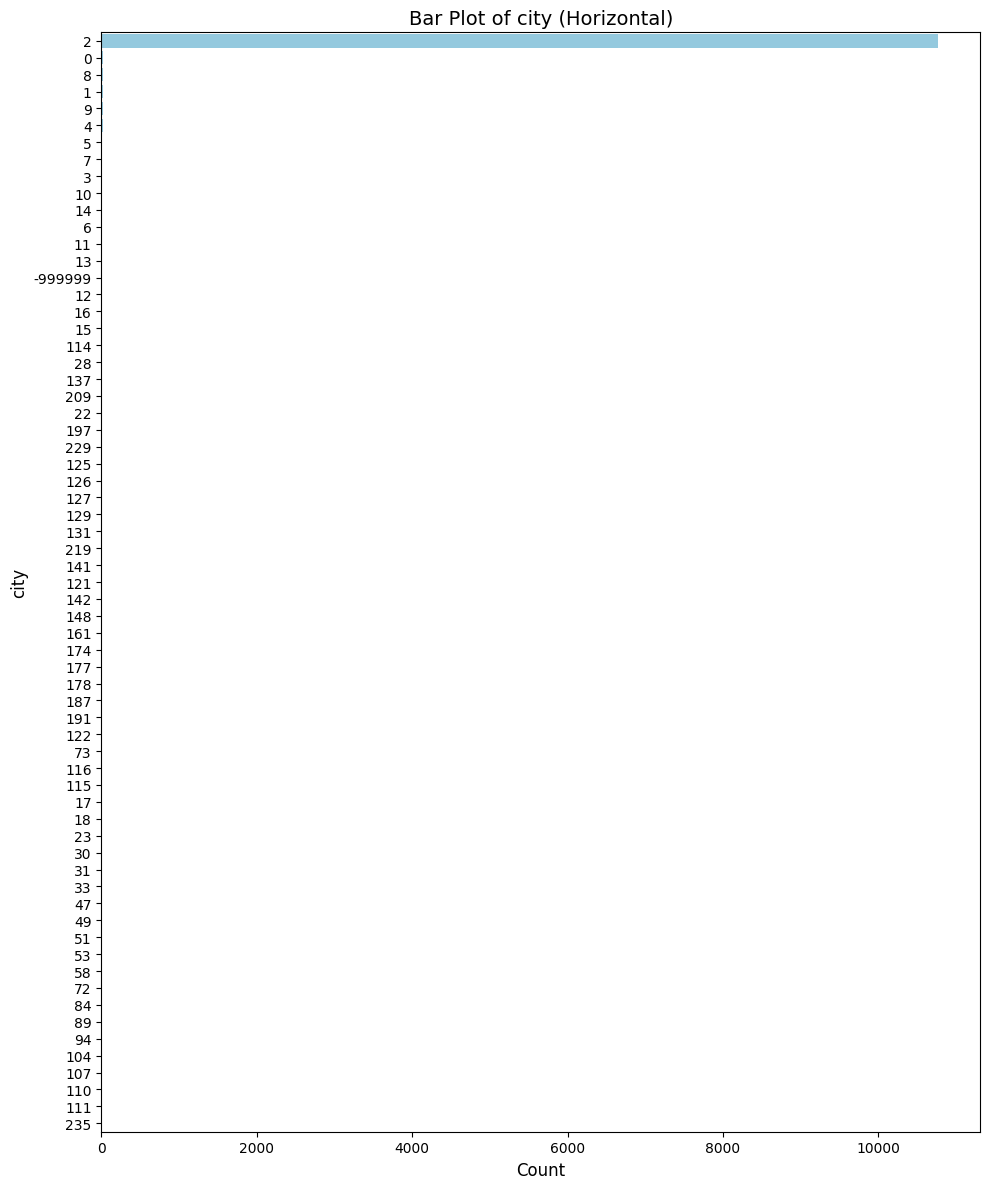

In [23]:
# Value counts
counts = customer_data['city'].value_counts(dropna=False)

# Print summary
print("Value counts for 'city':")
print(counts)
print("Number of unique categories:", customer_data['city'].nunique())
print("-" * 50)

# Plot
plt.figure(figsize=(10, 12))  # Increase figure size to accommodate many categories
sns.countplot(
    data=customer_data,
    y='city',
    order=counts.index,
    color='skyblue'
)
plt.title("Bar Plot of city (Horizontal)", fontsize=14)
plt.ylabel("city", fontsize=12)
plt.xlabel("Count", fontsize=12)
plt.tight_layout()
plt.show()


#### Observations for `city`

- **Dominant Category:**  
  - City code `2` has a significantly higher count (10,769) compared to all other city codes.

- **Long Tail Distribution:**  
  - There are 65 unique city codes in total. Most of them have relatively small counts, with only a few codes appearing frequently.

We can also notice a value that can be indicator of null "-999999"


#### 4. Prod_A

Value counts for 'prod_A':
prod_A
1    6433
0    4575
Name: count, dtype: int64
Number of unique categories: 2
--------------------------------------------------


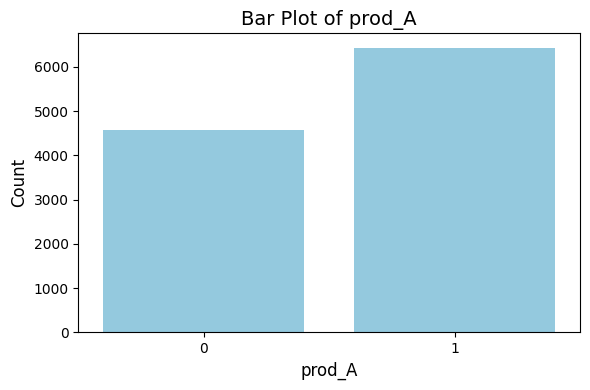

In [24]:
# Value counts for 'prod_A'
print("Value counts for 'prod_A':")
print(customer_data['prod_A'].value_counts(dropna=False))
print("Number of unique categories:", customer_data['prod_A'].nunique())
print("-" * 50)

# Bar plot
plt.figure(figsize=(6, 4))
sns.countplot(data=customer_data, x='prod_A', color='skyblue')
plt.title("Bar Plot of prod_A", fontsize=14)
plt.xlabel("prod_A", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.tight_layout()
plt.show()


#### Univariate Analysis of `prod_A`

- **Value Counts:**  
  - `1` (purchased Product A): 6433  
  - `0` (did not purchase Product A): 4575  

- **Observation:**  
  - Slightly more customers have purchased Product A than those who have not.  
  - The distribution is somewhat balanced, which may be useful for modeling. 


#### 5. Prod_B

Value counts for 'prod_B':
prod_B
1    7180
0    3828
Name: count, dtype: int64
Number of unique categories: 2
--------------------------------------------------


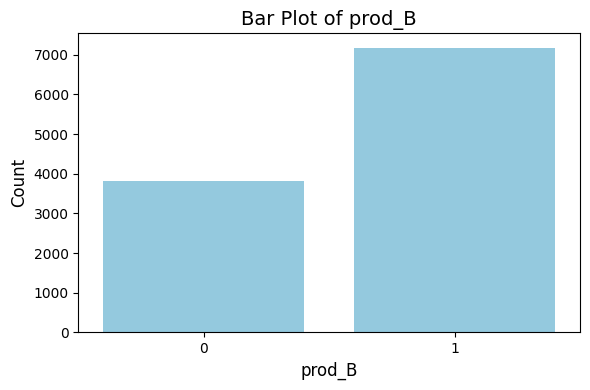

In [25]:
# Value counts for 'prod_B'
print("Value counts for 'prod_B':")
print(customer_data['prod_B'].value_counts(dropna=False))
print("Number of unique categories:", customer_data['prod_B'].nunique())
print("-" * 50)

# Bar plot
plt.figure(figsize=(6, 4))
sns.countplot(data=customer_data, x='prod_B', color='skyblue')
plt.title("Bar Plot of prod_B", fontsize=14)
plt.xlabel("prod_B", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.tight_layout()
plt.show()


#### Univariate Analysis of `prod_B`

- **Value Counts:**  
  - `1` (purchased Product B): 7180  
  - `0` (did not purchase Product B): 3828  

- **Observation:**  
  - The majority of customers (7180) purchased Product B, compared to 3828 who did not.  
  - This indicates a higher adoption rate for Product B within the dataset.


#### 6. type_A

Value counts for 'type_A':
type_A
3    6410
0    4575
6      23
Name: count, dtype: int64
Number of unique categories: 3
--------------------------------------------------


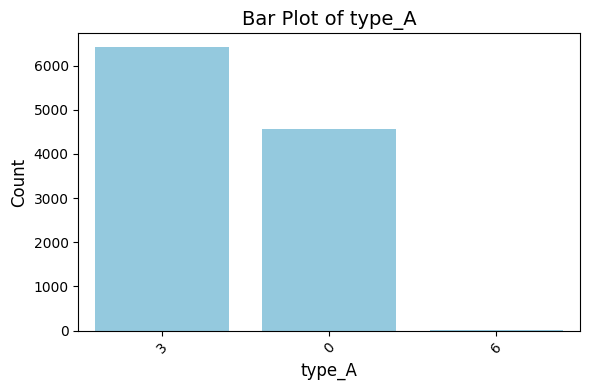

In [26]:
# Value counts for 'type_A'
print("Value counts for 'type_A':")
print(customer_data['type_A'].value_counts(dropna=False))
print("Number of unique categories:", customer_data['type_A'].nunique())
print("-" * 50)

# Bar plot
plt.figure(figsize=(6, 4))
sns.countplot(data=customer_data, x='type_A', color='skyblue', order=customer_data['type_A'].value_counts().index)
plt.title("Bar Plot of type_A", fontsize=14)
plt.xlabel("type_A", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=45)  # Rotate labels if needed
plt.tight_layout()
plt.show()


#### Univariate Analysis of `type_A`

- **Value Counts:**  
  - `3`: 6410  
  - `0`: 4575  
  - `6`: 23  

- **Observation:**  
  - Most customers who bought Product A are associated with category `3`.  
  - Category `6` is extremely small, indicating a rare product type for Product A.  
  - Category `0` also represents a sizable portion of the dataset. 


#### 7. type_B

Value counts for 'type_B':
type_B
3    6695
0    3828
6     452
9      33
Name: count, dtype: int64
Number of unique categories: 4
--------------------------------------------------


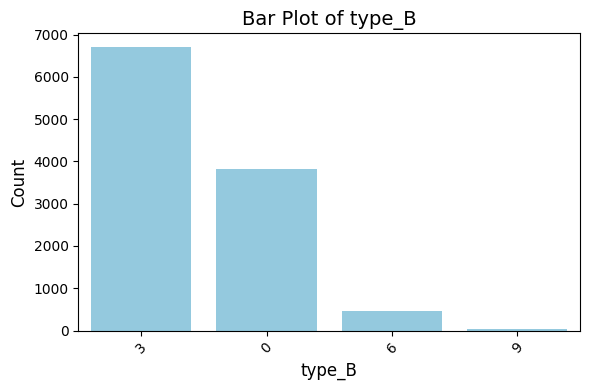

In [27]:
# Value counts for 'type_B'
print("Value counts for 'type_B':")
print(customer_data['type_B'].value_counts(dropna=False))
print("Number of unique categories:", customer_data['type_B'].nunique())
print("-" * 50)

# Bar plot
plt.figure(figsize=(6, 4))
sns.countplot(data=customer_data, x='type_B', color='skyblue', order=customer_data['type_B'].value_counts().index)
plt.title("Bar Plot of type_B", fontsize=14)
plt.xlabel("type_B", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


#### Univariate Analysis of `type_B`

- **Value Counts:**  
  - `3`: 6695  
  - `0`: 3828  
  - `6`: 452  
  - `9`: 33  

- **Observation:**  
  - Category `3` dominates Product B types, with `0` also quite common.  
  - Categories `6` and `9` are relatively rare, suggesting they might be niche product types. 


#### 8. Contract

Value counts for 'contract':
contract
2    11008
Name: count, dtype: int64
Number of unique categories: 1
--------------------------------------------------


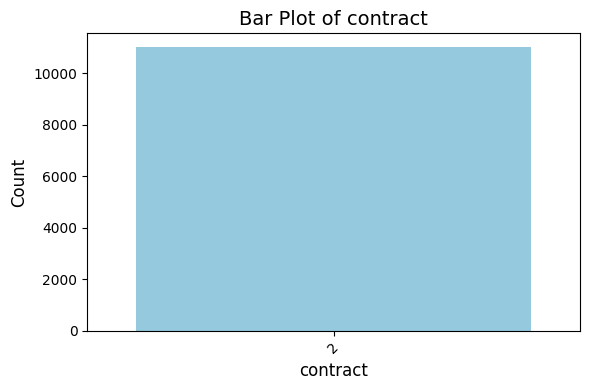

In [28]:
# Value counts for 'contract'
print("Value counts for 'contract':")
print(customer_data['contract'].value_counts(dropna=False))
print("Number of unique categories:", customer_data['contract'].nunique())
print("-" * 50)

# Bar plot
plt.figure(figsize=(6, 4))
sns.countplot(data=customer_data, x='contract', color='skyblue', order=customer_data['contract'].value_counts().index)
plt.title("Bar Plot of contract", fontsize=14)
plt.xlabel("contract", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


#### Univariate Analysis of `contract`

- **Value Counts:**  
  - `2`: 11008  

- **Observation:**  
  - This variable has only one unique category (`2`).  
  - With no variation, `contract` does not contribute any predictive information for modeling.


### Bivariate Analysis:  Numerical Variable Vs Numerical Variable:

#### 1. Heatmap Between Numerical variables:

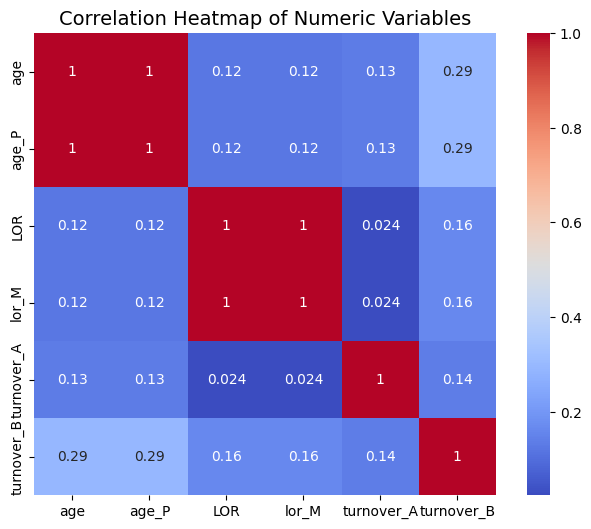

In [29]:

# Select numeric variables
num_vars = ['age', 'age_P', 'LOR', 'lor_M', 'turnover_A', 'turnover_B']

# 1. Correlation Heatmap
corr_matrix = customer_data[num_vars].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', square=True)
plt.title("Correlation Heatmap of Numeric Variables", fontsize=14)
plt.show()


#### Observations from the Correlation Heatmap

- **Age and Age of Partner (`age` and `age_P`)** have a correlation of **1.0**, indicating both columns have exactly the same information. This is what we also observed in the univariate analysis of these variables.

- **Length of Relationship (`LOR`)** and **Length of Relationship in Months (`lor_M`)** also have a perfect correlation (**1.0**). Also observed from their univariate analysis.

- There is a weak positive correlation (**0.29**) between **age** and **turnover_B**, suggesting older customers tend to spend slightly more on Product B.

- Other numerical variable pairs show very weak correlations (close to zero), indicating little to no linear relationship between them.


#### 2. Age vs LOR

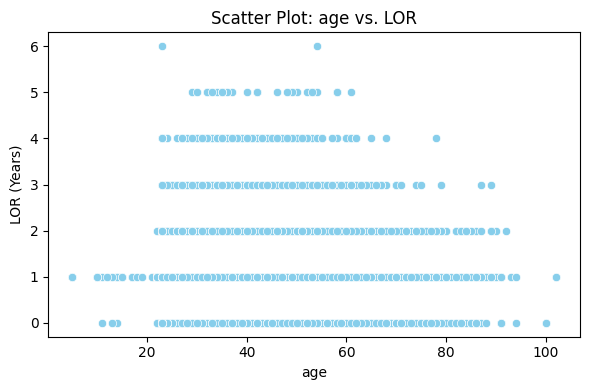

In [30]:
#  age vs. LOR
plt.figure(figsize=(6,4))
sns.scatterplot(x='age', y='LOR', data=customer_data, color='skyblue')
plt.title('Scatter Plot: age vs. LOR')
plt.xlabel('age')
plt.ylabel('LOR (Years)')
plt.tight_layout()
plt.show()


There is no strong linear trend, indicating a very weak or no clear relationship between customer age and length of relationship. We also got to know this from the heatmap from above.

#### 3. Age vs turnover_A

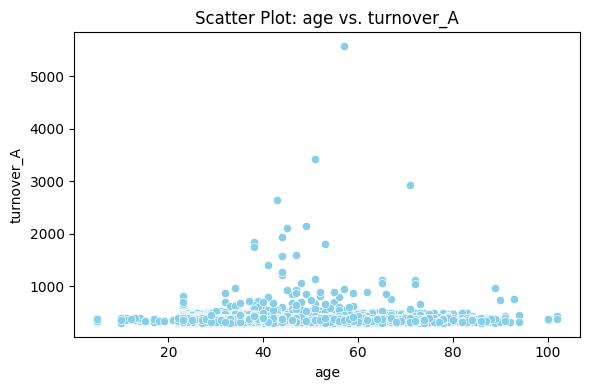

In [31]:
# age vs. turnover_A
plt.figure(figsize=(6,4))
sns.scatterplot(x='age', y='turnover_A', data=customer_data, color='skyblue')
plt.title('Scatter Plot: age vs. turnover_A')
plt.xlabel('age')
plt.ylabel('turnover_A')
plt.tight_layout()
plt.show()


The scatter plot between age and `turnover_A` indicates no distinct linear relationship between these two variables. Most customers, regardless of age, tend to have lower spending values with some isolated higher-spending outliers observed in mid-age groups.

#### 4. Age vs turnover_B

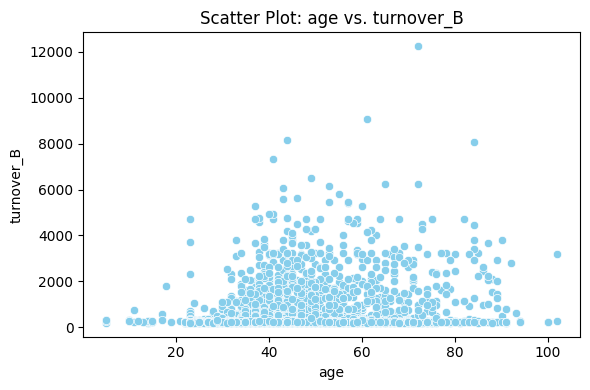

In [32]:
#  age vs. turnover_B
plt.figure(figsize=(6,4))
sns.scatterplot(x='age', y='turnover_B', data=customer_data, color='skyblue')
plt.title('Scatter Plot: age vs. turnover_B')
plt.xlabel('age')
plt.ylabel('turnover_B')
plt.tight_layout()
plt.show()


- The scatter plot of `age` versus `turnover_B` shows no clear linear correlation.
- Most customers, regardless of their age, have relatively low `turnover_B` values.
- There are several noticeable outliers, particularly among customers aged between 40 and 60, indicating higher spending in that segment.

#### 5. LOR vs turnover_A

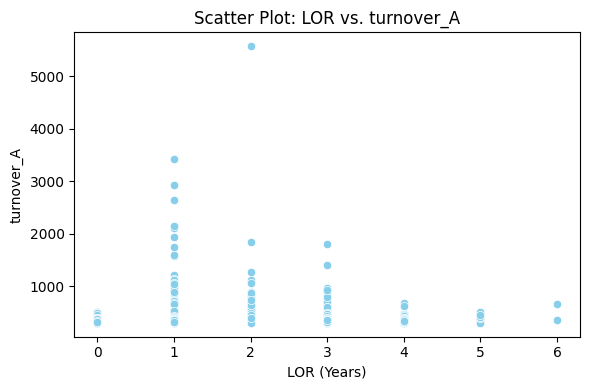

In [33]:
# LOR vs. turnover_A
plt.figure(figsize=(6,4))
sns.scatterplot(x='LOR', y='turnover_A', data=customer_data, color='skyblue')
plt.title('Scatter Plot: LOR vs. turnover_A')
plt.xlabel('LOR (Years)')
plt.ylabel('turnover_A')
plt.tight_layout()
plt.show()


- The scatter plot between `LOR` (Length of Relationship in years) and `turnover_A` does not reveal any strong linear correlation.
- Most observations cluster around the lower turnover values regardless of the relationship length.
- A few notable outliers appear particularly at 1 and 2 years of relationship length, indicating occasional higher spending among customers at these stages.

#### 6. LOR vs turnover_B

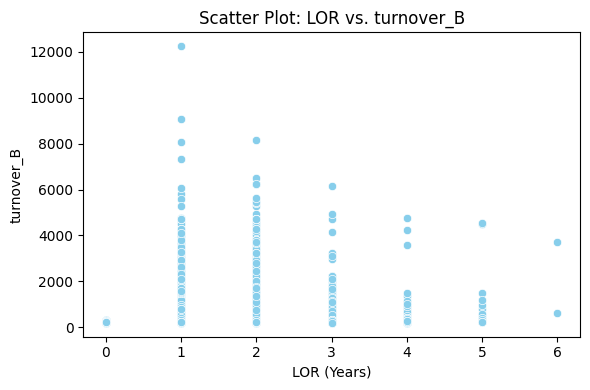

In [34]:
# LOR vs. turnover_B
plt.figure(figsize=(6,4))
sns.scatterplot(x='LOR', y='turnover_B', data=customer_data, color='skyblue')
plt.title('Scatter Plot: LOR vs. turnover_B')
plt.xlabel('LOR (Years)')
plt.ylabel('turnover_B')
plt.tight_layout()
plt.show()


- The scatter plot between `LOR` (Length of Relationship in years) and `turnover_B` does not indicate a strong correlation.
- Most data points are concentrated in lower turnover ranges, but significant outliers appear for relationships of 1 to 2 years.
- Customers with shorter relationship durations (around 1–3 years) exhibit the highest spending (turnover), suggesting peak customer spending occurs early in the relationship.

### Bivariate Analysis:  Categorical Variable Vs Categorical Variable:

#### 1. Target Vs Loyalty

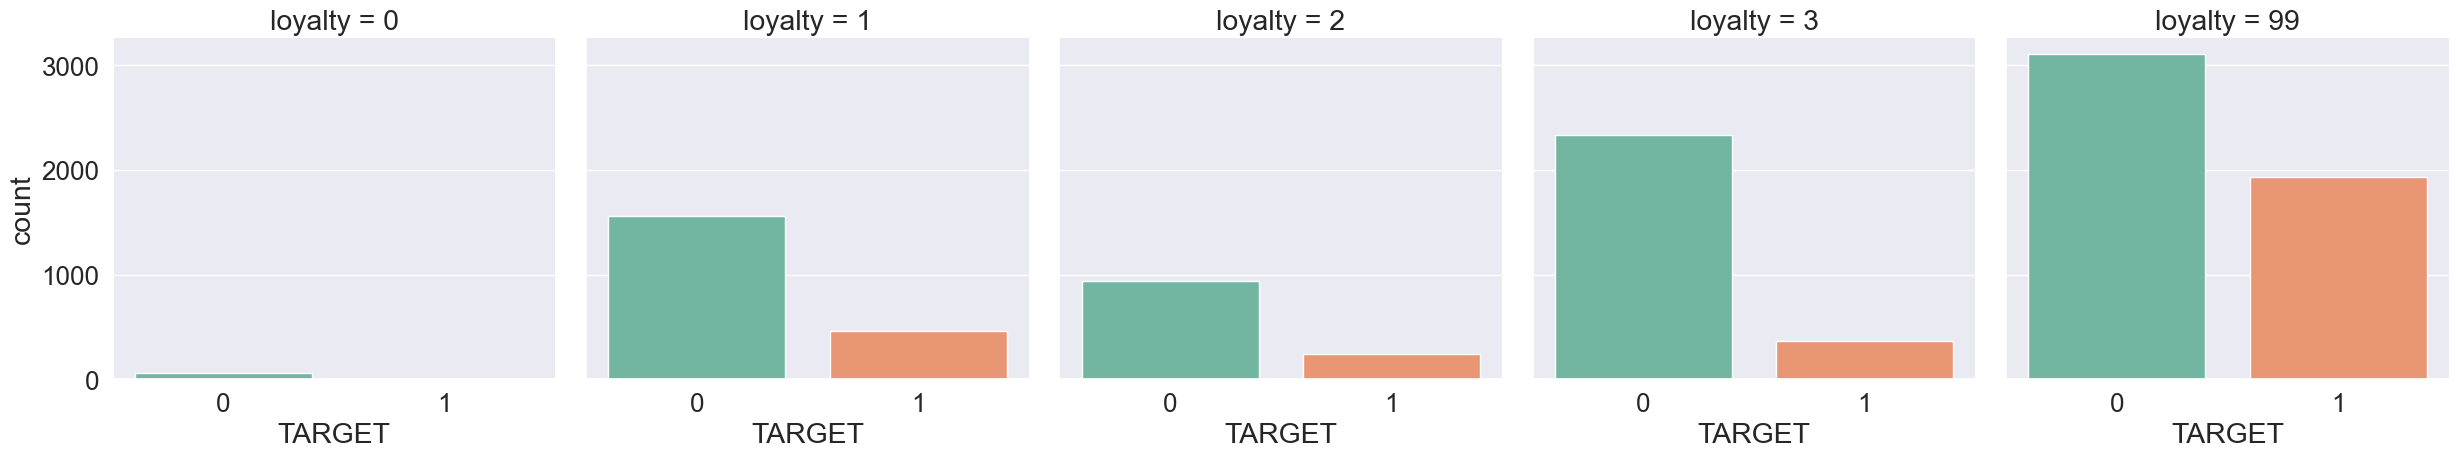

In [35]:
# Increase overall font size
sns.set(font_scale=1.7)

# Create the catplot with a custom color palette
sns.catplot(
    data=customer_data,
    x='TARGET',
    col='loyalty',
    kind='count',
    col_wrap=5,
    palette='Set2'  # You can also try palettes like 'husl', 'pastel', 'bright', etc.
)

plt.show()

##### Observations from Loyalty vs. TARGET (Stacked Bar Plot)

- Loyalty category `99` has the highest number of customers, followed by category `3`. The majority of customers in these categories fall under TARGET class `0` .
- Categories `1` and `2` have fewer customers, but a relatively noticeable portion of them belong to the TARGET class `1`.
- Loyalty category `0` has very few observations, and all of them are mostly negative outcomes (`TARGET = 0`).
- There's a clear indication of imbalance in each loyalty category favoring TARGET class `0`, suggesting TARGET positive outcomes (`1`) are less frequent across all loyalty levels.


#### 2. Product A vs Target

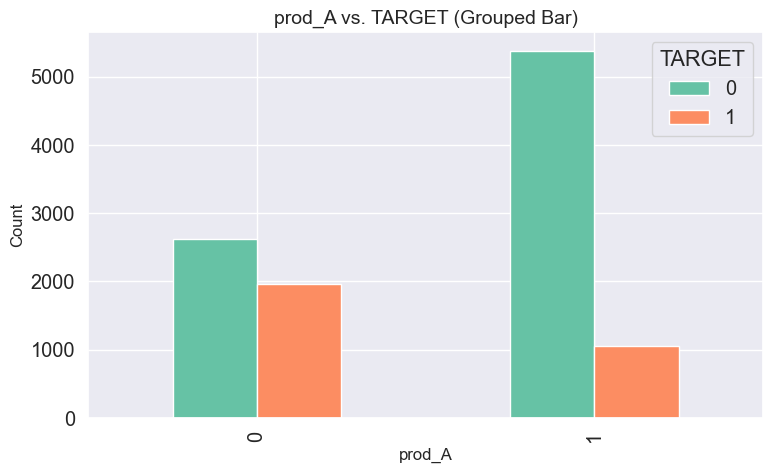

In [36]:
# Increase overall font size
sns.set(font_scale=1.3)

# Create a custom palette with 2 colors using Seaborn's Set2 palette
palette = sns.color_palette("Set2", 2)

# Group the data by 'prod_A' and 'TARGET'
grouped_data = customer_data.groupby(['prod_A', 'TARGET']).size().unstack(fill_value=0)

# Plot the grouped bar chart (non-stacked) using the custom color palette
grouped_data.plot(kind='bar', stacked=False, figsize=(8, 5), color=palette)
plt.title("prod_A vs. TARGET (Grouped Bar)", fontsize=14)
plt.xlabel("prod_A", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.legend(title="TARGET")
plt.tight_layout()
plt.show()

- The category `prod_A=1` has a higher overall count compared to `prod_A=0`.
- However, the proportion of the target variable (1) relative to the non-target variable (0) appears slightly higher within the category `prod_A=0` compared to `prod_A=1`, suggesting a potential relationship between `prod_A` and the target variable.

#### 3. Product B vs Target

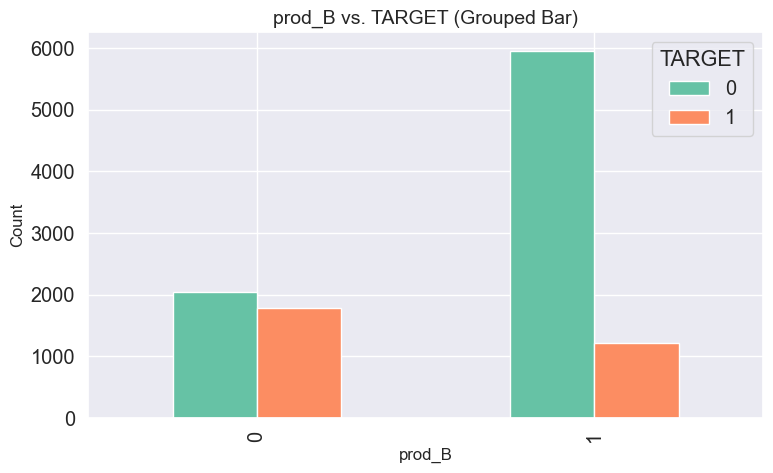

In [37]:
# Increase overall font size
sns.set(font_scale=1.3)

# Create a custom palette with 2 colors using Seaborn's Set2 palette
palette = sns.color_palette("Set2", 2)

# Group the data by 'prod_B' and 'TARGET'
grouped_data = customer_data.groupby(['prod_B', 'TARGET']).size().unstack(fill_value=0)

# Plot the grouped (non-stacked) bar chart using the custom color palette
grouped_data.plot(kind='bar', stacked=False, figsize=(8, 5), color=palette)
plt.title("prod_B vs. TARGET (Grouped Bar)", fontsize=14)
plt.xlabel("prod_B", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.legend(title="TARGET")
plt.tight_layout()
plt.show()

- The bar plot indicates that customers with `prod_B = 1` significantly outnumber those with `prod_B = 0`.
- However, the proportion of positive `TARGET` outcomes appears higher among customers where `prod_B = 0`, indicating a potential association between having or not having `prod_B` and the likelihood of the target outcome.

#### 4. Type A vs Target

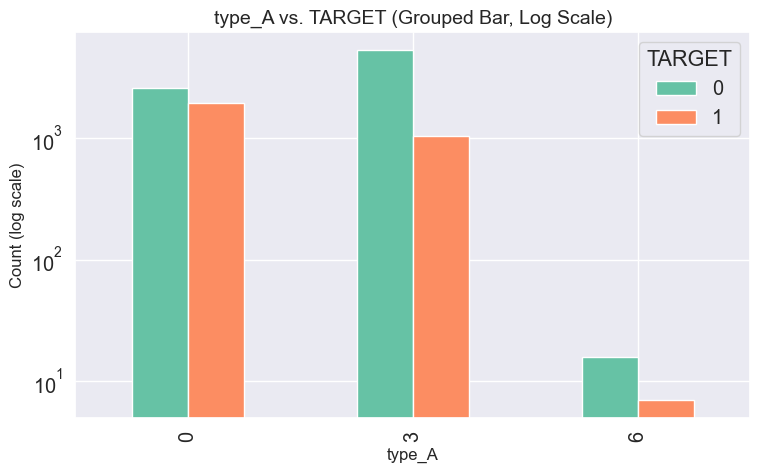

In [38]:
import seaborn as sns
import functools as _ft
if not getattr(sns, "_palette_hue_patch", False):
    for _f in ("countplot","barplot","boxplot","violinplot","stripplot","swarmplot","pointplot","boxenplot"):
        _o = getattr(sns, _f, None)
        if _o is None:
            continue
        def _w(*a, _o=_o, **k):
            if k.get("palette") is not None and "hue" not in k:
                if "x" in k:
                    k["hue"] = k["x"]
                elif "y" in k:
                    k["hue"] = k["y"]
                k.setdefault("legend", False)
            return _o(*a, **k)
        setattr(sns, _f, _ft.wraps(_o)(_w))
    sns._palette_hue_patch = True
import matplotlib.pyplot as plt

# Increase overall font size
sns.set(font_scale=1.3)

# Create a custom palette with 2 colors using Seaborn's Set2 palette
palette = sns.color_palette("Set2", 2)

# Group the data by 'type_A' and 'TARGET'
grouped_data = customer_data.groupby(['type_A', 'TARGET']).size().unstack(fill_value=0)

# Plot the grouped (non-stacked) bar chart using the custom color palette
ax = grouped_data.plot(kind='bar', stacked=False, figsize=(8, 5), color=palette)
ax.set_title("type_A vs. TARGET (Grouped Bar, Log Scale)", fontsize=14)
ax.set_xlabel("type_A", fontsize=12)
ax.set_ylabel("Count (log scale)", fontsize=12)
ax.legend(title="TARGET")
plt.tight_layout()

# Apply a logarithmic scale to the y-axis
ax.set_yscale('log')

plt.show()


1. **Dominance of `type_A = 3`**  
   - The highest counts for both `TARGET` = 0 and `TARGET` = 1 occur when `type_A = 3`, indicating it is the most frequent category.

2. **Class Imbalance**  
   - There are consistently more observations labeled `TARGET` = 0 than `TARGET` = 1 across all `type_A` categories.

3. **Log Scale Visualization**  
   - The log scale on the y-axis helps reveal the differences more clearly, even when counts vary widely.


#### 5. Type B vs Target

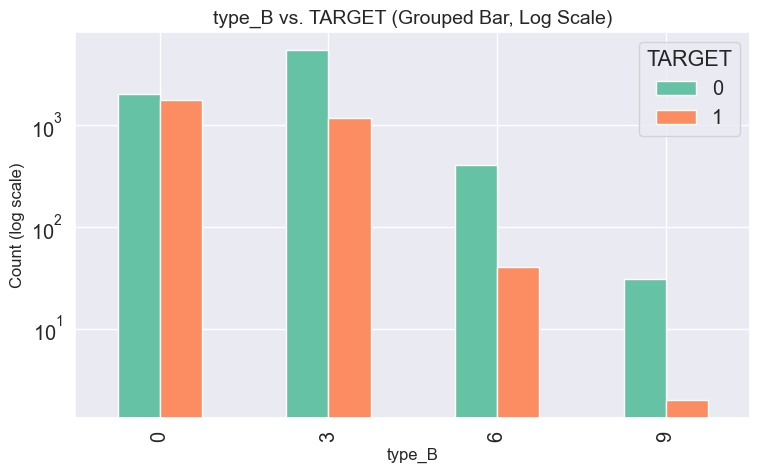

In [39]:
# Increase overall font size
sns.set(font_scale=1.3)

# Create a custom palette with 2 colors using Seaborn's Set2 palette
palette = sns.color_palette("Set2", 2)

# Group the data by 'type_A' and 'TARGET'
grouped_data = customer_data.groupby(['type_B', 'TARGET']).size().unstack(fill_value=0)

# Plot the grouped (non-stacked) bar chart using the custom color palette
ax = grouped_data.plot(kind='bar', stacked=False, figsize=(8, 5), color=palette)
ax.set_title("type_B vs. TARGET (Grouped Bar, Log Scale)", fontsize=14)
ax.set_xlabel("type_B", fontsize=12)
ax.set_ylabel("Count (log scale)", fontsize=12)
ax.legend(title="TARGET")
plt.tight_layout()

# Apply a logarithmic scale to the y-axis
ax.set_yscale('log')

plt.show()


1. **Dominant Categories**  
   - Categories `type_B = 0` and `type_B = 3` show the highest counts for both `TARGET = 0` and `TARGET = 1`.

2. **Class Imbalance**  
   - Across all `type_B` categories, `TARGET = 0` consistently outnumbers `TARGET = 1`, indicating a notable imbalance.

3. **Logarithmic Scale**  
   - The log scale on the y-axis highlights variations in smaller counts, ensuring that differences across categories are more visually apparent.

### Bivariate Analysis:  Numerical Variable Vs Categorical Variable:

#### 1. Age vs Target

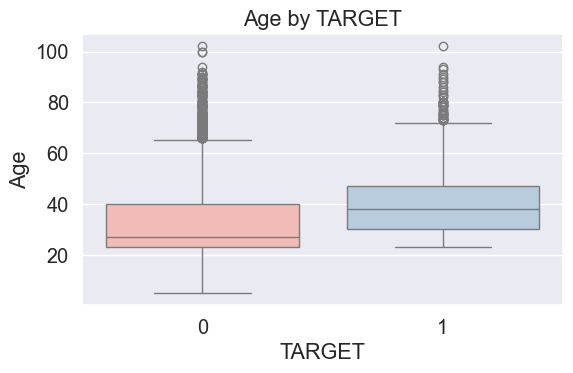

In [40]:
plt.figure(figsize=(6,4))
sns.boxplot(x='TARGET', y='age', data=customer_data, palette='Pastel1')
plt.title('Age by TARGET')
plt.xlabel('TARGET')
plt.ylabel('Age')
plt.tight_layout()
plt.show()

- Customers with **TARGET = 0** generally have a slightly wider age distribution, ranging from younger to older customers, but with a lower median age.
- Customers with **TARGET = 1** tend to be older, having a higher median age.
- The presence of outliers is noticeable for both categories, with some customers having very high ages (80-100 years old), though these outliers appear more prevalent for **TARGET = 0**.
- The overlapping interquartile ranges suggest age alone is not strongly predictive of the TARGET variable.


#### 2. LOR vs Target

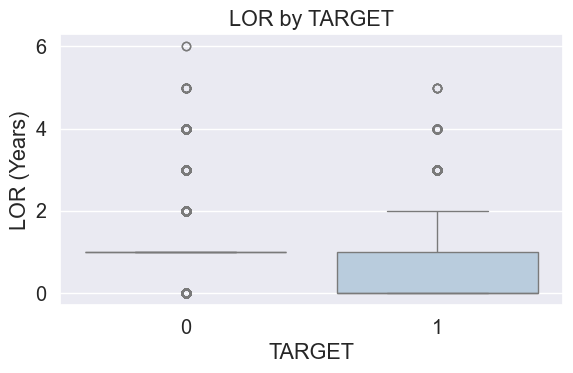

In [41]:
plt.figure(figsize=(6,4))
sns.boxplot(x='TARGET', y='LOR', data=customer_data, palette='Pastel1')
plt.title('LOR by TARGET')
plt.xlabel('TARGET')
plt.ylabel('LOR (Years)')
plt.tight_layout()
plt.show()


- Customers with **TARGET = 1** (buy new product) generally have higher variability in Length of Relationship (LOR), with a median around 1 year, and some customers extending to about 3 years.
- Customers with **TARGET = 0** predominantly have a uniform LOR around 1 year, with very minimal variability.
- There are visible outliers in both groups, suggesting the presence of customers with unusually high lengths of relationship, particularly in the TARGET = 1 category.


#### 3. Turnover_A vs Target

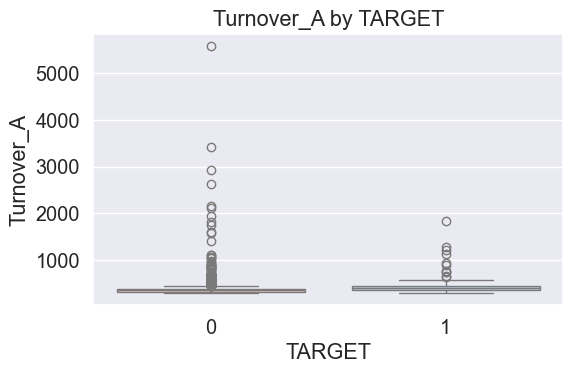

In [42]:
plt.figure(figsize=(6,4))
sns.boxplot(x='TARGET', y='turnover_A', data=customer_data, palette='Pastel1')
plt.title('Turnover_A by TARGET')
plt.xlabel('TARGET')
plt.ylabel('Turnover_A')
plt.tight_layout()
plt.show()


- **Median turnover_A** is relatively similar for both **TARGET = 0** and **TARGET = 1**.
- There are many **outliers**, especially within the **TARGET = 0** category, indicating some customers exhibit significantly higher turnover_A values.
- Overall, the distribution appears to be highly skewed, with most customers showing lower turnover_A values irrespective of their TARGET category.

#### 4. Turnover_B vs Target

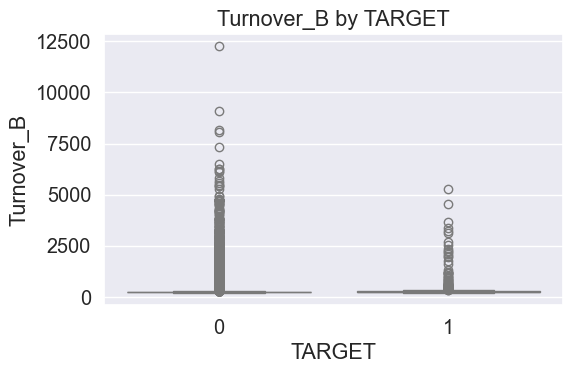

In [43]:
plt.figure(figsize=(6,4))
sns.boxplot(x='TARGET', y='turnover_B', data=customer_data, palette='Pastel1')
plt.title('Turnover_B by TARGET')
plt.xlabel('TARGET')
plt.ylabel('Turnover_B')
plt.tight_layout()
plt.show()


- The boxplot shows **significant outliers**, especially for `TARGET=0`, indicating that some customers have exceptionally high turnover_B values.
- Customers with `TARGET=0` generally exhibit a higher variability in turnover_B compared to those with `TARGET=1`.
- Most customers across both categories have relatively low turnover_B values, suggesting a skewed distribution.

#### 5. Age by loyalty

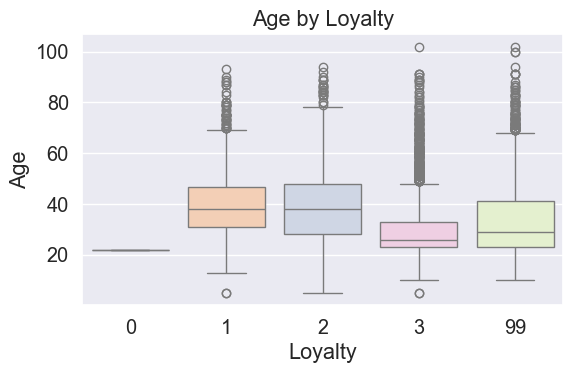

In [44]:
plt.figure(figsize=(6,4))
sns.boxplot(x='loyalty', y='age', data=customer_data, palette='Pastel2')
plt.title('Age by Loyalty')
plt.xlabel('Loyalty')
plt.ylabel('Age')
plt.tight_layout()
plt.show()


- **Loyalty category `0`** consists primarily of young customers with minimal variability.
- **Loyalty category `1` and `2`** have customers with similar median ages (~38–40), but category `2` has higher variability and category `1` has more outliers.
- **Category `3`** includes younger customers compared to other groups, with a median age around 25.
- **Loyalty category `99`** show significant variability, indicating that this group primarily consists of older customers.

#### 6. Loyalty by LOR

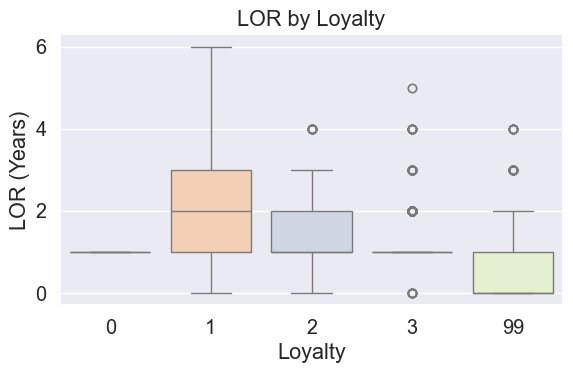

In [45]:
plt.figure(figsize=(6,4))
sns.boxplot(x='loyalty', y='LOR', data=customer_data, palette='Pastel2')
plt.title('LOR by Loyalty')
plt.xlabel('Loyalty')
plt.ylabel('LOR (Years)')
plt.tight_layout()
plt.show()


- **Loyalty category `0`** shows consistently short Length of Relationship (LOR) (~1 year) with no variability.
- **Loyalty category `1`** has the widest range and the highest median LOR (~2 years), indicating stable, longer-term customers.
- **Loyalty category `2`** has a slightly lower median LOR (~2 years).
- **Category `3`** and **category `99`** have relatively lower median LORs (around 1 year), suggesting these groups represent newer or less engaged customers.

#### 7. Purchase of Product A by Age

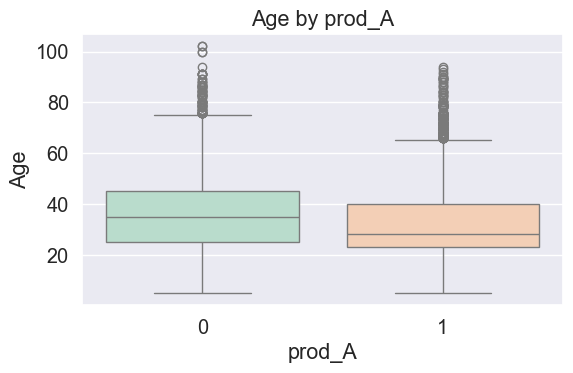

In [46]:
plt.figure(figsize=(6,4))
sns.boxplot(x='prod_A', y='age', data=customer_data, palette='Pastel2')
plt.title('Age by prod_A')
plt.xlabel('prod_A')
plt.ylabel('Age')
plt.tight_layout()
plt.show()


- Customers who **did not purchase Product A (0)** have a slightly higher median age (~35 years) compared to those who **purchased Product A (1)** (~30 years).
- The age distributions for both groups are fairly similar, indicating minimal age influence on the decision to purchase Product A.
- Outliers exist primarily in older age groups (above ~75 years) across both categories.

#### 8. Purchase of Product B by Age

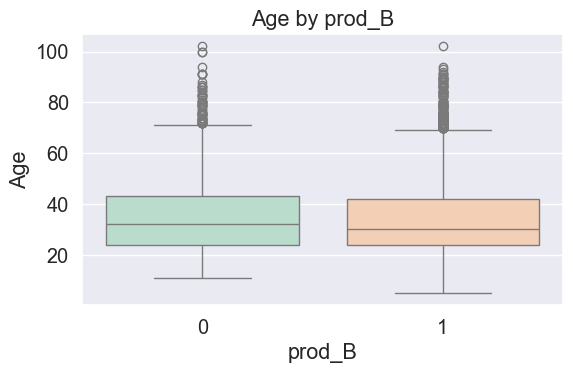

In [47]:
plt.figure(figsize=(6,4))
sns.boxplot(x='prod_B', y='age', data=customer_data, palette='Pastel2')
plt.title('Age by prod_B')
plt.xlabel('prod_B')
plt.ylabel('Age')
plt.tight_layout()
plt.show()


- Customers who **purchased Product B (1)** tend to have a slightly lower median age (~33 years) compared to those who **did not purchase Product B (0)** (~35 years).
- Both groups show a broad distribution of ages, indicating age may not strongly differentiate Product B purchases.
- Several outliers appear in the older age range (75+ years), primarily among customers who did not purchase the product.

#### 9. Turnover of A by their product Type

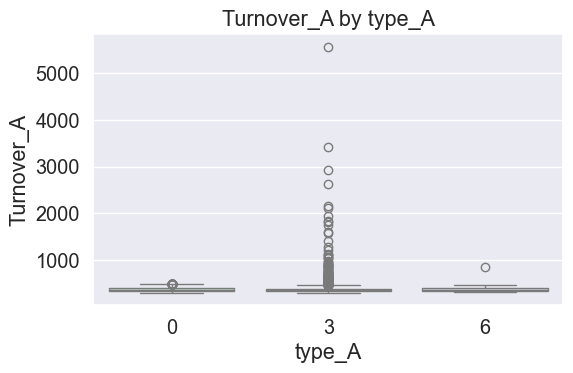

In [48]:
plt.figure(figsize=(6,4))
sns.boxplot(x='type_A', y='turnover_A', data=customer_data, palette='Pastel2')
plt.title('Turnover_A by type_A')
plt.xlabel('type_A')
plt.ylabel('Turnover_A')
plt.tight_layout()
plt.show()


- Product Type **3** has a higher median turnover compared to Types **0** and **6**.
- Most customers belong to Type **3**, exhibiting considerable variability and notable outliers in turnover.
- Product Types **0** and **6** have relatively lower turnover distributions and fewer extreme values.

#### 10. Turnover of B by their product type

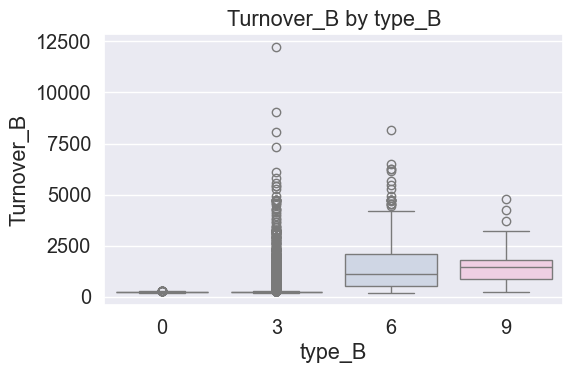

In [49]:
plt.figure(figsize=(6,4))
sns.boxplot(x='type_B', y='turnover_B', data=customer_data, palette='Pastel2')
plt.title('Turnover_B by type_B')
plt.xlabel('type_B')
plt.ylabel('Turnover_B')
plt.tight_layout()
plt.show()


- Product Type **3** shows significant variability in turnover with many extreme outliers, suggesting diverse customer spending behavior.
- Types **6** and **9** exhibit higher median turnover, with Type **6** having broader variability than Type **9**.
- Product Type **0** has consistently low turnover values, indicating lower revenue generation from these customers.

## Data Preparation 

### 1. Handling Redundant Variables: Dimensionality Reduction

In [50]:
customer_data.drop(['age_P', 'lor_M'], axis=1, inplace=True)

In [51]:
customer_data.columns

Index(['TARGET', 'loyalty', 'age', 'city', 'LOR', 'prod_A', 'type_A', 'type_B',
       'prod_B', 'turnover_A', 'turnover_B', 'contract'],
      dtype='object')

From the exploratory analysis, we noticed pairs of variables with perfect correlation (age & age_P; LOR & lor_M). To avoid multicollinearity, so we are handling them by dropping from the data frame.

### 2. Handling -999999 value in the city column

In [52]:
# Counting occurrences of -999999
num_neg999999 = (customer_data['city'] == -999999).sum()

# Calculating percentage
percentage_neg999999 = (num_neg999999 / len(customer_data)) * 100

print(f"Percentage of -999999 in 'city' column: {percentage_neg999999:.2f}%")

Percentage of -999999 in 'city' column: 0.07%


In [53]:
# Replace -999999 with 2 (most frequent city)
customer_data['city'] = customer_data['city'].replace(-999999, 2)

# Verify replacement
print(customer_data['city'].value_counts())

city
2      10777
0         20
8         17
1         17
9         16
       ...  
104        1
107        1
110        1
111        1
235        1
Name: count, Length: 64, dtype: int64


The `city` column had `-999999` as placeholder values representing missing data. Since only **0.07%** of the observations had this placeholder, we replaced `-999999` with the most frequent city value (`2`). This approach preserved useful information from other columns without significantly altering the data distribution.

### 3. Removing Non-informative Variables: Dimensionality Reduction

In [54]:
customer_data.drop('contract', axis=1, inplace=True)
customer_data.columns

Index(['TARGET', 'loyalty', 'age', 'city', 'LOR', 'prod_A', 'type_A', 'type_B',
       'prod_B', 'turnover_A', 'turnover_B'],
      dtype='object')

The `contract` variable has a single unique value and thus provides no predictive value. So, we are removing it from the data set.

### 4. Handling Outliers (Turnover_A and Turnover_B)

To address outliers in **`turnover_A`** and **`turnover_B`**, logarithmic transformations can be applied. This approach helps normalize the skewed distributions, preserving valuable information from high-value customers who may make bulk purchases, without allowing extreme values to bias our predictive models.

In [55]:
from sklearn.preprocessing import PowerTransformer
# Apply Box-Cox transformation
# Check for zeros or negative values
(customer_data[['turnover_A', 'turnover_B']] <= 0).sum()

turnover_A    0
turnover_B    0
dtype: int64

In [56]:
pt = PowerTransformer(method='box-cox')
customer_data[['turnover_A_boxcox', 'turnover_B_boxcox']] = pt.fit_transform(customer_data[['turnover_A', 'turnover_B']])

In [57]:
customer_data[['turnover_A_boxcox', 'turnover_B_boxcox']].head()

,turnover_A_boxcox,turnover_B_boxcox
0,-0.706074,0.687482
1,0.728694,1.039941
2,-0.445272,2.436374
3,1.514769,0.145817
4,0.546396,1.071100


We applied the **Box-Cox transformation** to the columns **turnover_A** and **turnover_B** to reduce skewness and handle outliers without removing significant data points. This transformation normalizes the distribution of these variables, making them more suitable for modeling and reducing potential bias in predictions.


Reference : Module 6 of DAV 6150 and 
https://thedocs.worldbank.org/en/doc/20f02031de132cc3d76b91b5ed8737d0-0050012017/related/lecture-12-1.pdf

### 5. Handling Outliers (Age)

In [58]:
customer_data['age'] = np.clip(customer_data['age'], customer_data['age'].quantile(0.01), customer_data['age'].quantile(0.99))

To handle extreme outliers in the `age` column, we applied **percentile-based clipping**. Specifically, we replaced values below the **1st percentile** with the 1st percentile value and values above the **99th percentile** with the 99th percentile value. This reduces the influence of outliers, resulting in a more robust dataset for modeling. As the min age of the customer and the max age of the customer we got to know from the EDA are 5 and 120 that is almost not possible to be real.

In [59]:
customer_data.head()

,TARGET,loyalty,age,city,LOR,prod_A,type_A,type_B,prod_B,turnover_A,turnover_B,turnover_A_boxcox,turnover_B_boxcox
0,1,99,66.0,2,0,0,0,0,0,333.561114,264.721010,-0.706074,0.687482
1,1,1,45.0,2,3,1,3,3,1,394.735699,284.904978,0.728694,1.039941
2,1,1,42.0,2,2,1,3,6,1,342.180990,1175.589721,-0.445272,2.436374
3,1,99,31.0,2,0,0,0,0,0,453.757916,242.341754,1.514769,0.145817
4,1,99,62.0,2,0,0,0,0,0,384.577469,287.008370,0.546396,1.071100


In [60]:
customer_data.drop(['turnover_A', 'turnover_B'], axis=1, inplace=True)
customer_data.columns

Index(['TARGET', 'loyalty', 'age', 'city', 'LOR', 'prod_A', 'type_A', 'type_B',
       'prod_B', 'turnover_A_boxcox', 'turnover_B_boxcox'],
      dtype='object')

Since we are left with very few columns doing **PCA**, **forward/backward Selection** doesn't make sense.

### 6. Forward selection

In [61]:
# mlxtend pinned in requirements.txt

we install the **mlxtend library**, which provides implementations of various feature selection algorithms, including Sequential Feature Selector (SFS), which we’ll use for forward feature selection.

In [62]:
# scikit-learn pinned in requirements.txt

In [63]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from mlxtend.feature_selection import SequentialFeatureSelector as SFS

# Separate features (X) and target (y)
X = customer_data.drop('TARGET', axis=1)
y = customer_data['TARGET']

# Split into train/test sets
# Adjust test_size and random_state as desired
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.3, 
                                                    random_state=42,
                                                    stratify=y)  # stratify to preserve class distribution

# Initialize the Logistic Regression model
lr = LogisticRegression()

# Set up forward selection to choose exactly 4 features
# scoring='f1' is used for imbalanced classification scenarios
sfs = SFS(lr,
          k_features=4,         # pick 4 features
          forward=False,         # forward selection
          floating=True,       # no floating steps
          verbose = 2,
          scoring='f1',         # F1 score for imbalanced data
          #cv=5,                 # 5-fold cross-validation
          n_jobs=-1)            # use all available CPU cores

# Fit the selector on the training data
sfs1 = sfs.fit(X_train, y_train)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 24 concurrent workers.


[Parallel(n_jobs=-1)]: Done   5 out of  10 | elapsed:    2.6s remaining:    2.6s
[Parallel(n_jobs=-1)]: Done  10 out of  10 | elapsed:    2.7s finished

[2026-06-08 20:26:45] Features: 9/4 -- score: 0.5993310038097085[Parallel(n_jobs=-1)]: Using backend LokyBackend with 24 concurrent workers.


[Parallel(n_jobs=-1)]: Done   2 out of   9 | elapsed:    1.0s remaining:    3.8s
[Parallel(n_jobs=-1)]: Done   7 out of   9 | elapsed:    1.0s remaining:    0.2s
[Parallel(n_jobs=-1)]: Done   9 out of   9 | elapsed:    1.0s finished

[2026-06-08 20:26:46] Features: 8/4 -- score: 0.6008488282239086[Parallel(n_jobs=-1)]: Using backend LokyBackend with 24 concurrent workers.


[Parallel(n_jobs=-1)]: Done   6 out of   8 | elapsed:    0.8s remaining:    0.2s
[Parallel(n_jobs=-1)]: Done   8 out of   8 | elapsed:    0.8s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 24 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   2 | elapsed:    0.0s finished

[2026-06-08 20:26:47] Features: 7/4 -- score: 0.5968674519459958[Parallel(n_jobs=-1)]: Using backend LokyBackend with 24 concurrent workers.


[Parallel(n_jobs=-1)]: Done   4 out of   7 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done   7 out of   7 | elapsed:    0.0s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 24 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:    0.0s finished

[2026-06-08 20:26:48] Features: 6/4 -- score: 0.5948813416542144[Parallel(n_jobs=-1)]: Using backend LokyBackend with 24 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   6 | elapsed:    0.0s remaining:    0.0s


[Parallel(n_jobs=-1)]: Done   6 out of   6 | elapsed:    0.0s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 24 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   4 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done   4 out of   4 | elapsed:    0.0s finished

[2026-06-08 20:26:48] Features: 5/4 -- score: 0.5896845835488139[Parallel(n_jobs=-1)]: Using backend LokyBackend with 24 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   5 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.0s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 24 concurrent workers.


[Parallel(n_jobs=-1)]: Done   3 out of   5 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:    0.0s finished

[2026-06-08 20:26:48] Features: 4/4 -- score: 0.576122823643803

- The first parameter is the model name, lr, which is basically our logistic regression model.

- **k_features** tells us how many features should be selected. We’ve passed 4 so the model will train until 4 features are selected.

Now here’s the difference between implementing the Backward Elimination Method and the Forward Feature Selection method, the parameter forward will be set to True. This means training the forward feature selection model. We set it as False during the backward feature elimination technique.

- verbose = 2 will allow us to bring the model summary at each iteration.

- since, it is a regression model scoring based on the F1 as it is highly imbalanced data, we will set scoring = ‘F1’


reference : https://www.analyticsvidhya.com/blog/2021/04/forward-feature-selection-and-its-implementation/

In [64]:
# Get the selected feature names
selected_features = list(sfs1.k_feature_names_)
print("Selected features:", selected_features)

Selected features: ['age', 'type_B', 'turnover_A_boxcox', 'turnover_B_boxcox']


We can see that the model was trained until four features were selected.

In [65]:
# Optionally, we are evaluating the model with these features
X_train_selected = sfs1.transform(X_train)
X_test_selected = sfs1.transform(X_test)

lr.fit(X_train_selected, y_train)

# Evaluate the model
train_score = lr.score(X_train_selected, y_train)
test_score = lr.score(X_test_selected, y_test)
print(f"Training Accuracy: {train_score:.4f}")
print(f"Test Accuracy: {test_score:.4f}")


Training Accuracy: 0.8045
Test Accuracy: 0.8153


## Prepped Data Review 

Lets do the prepped Data Review to the selected features above i.e.['age', 'type_B', 'turnover_A_boxcox', 'turnover_B_boxcox'] and the remaining variables we did data preparation for.

### 1. Age

Summary statistics for 'age':
count    11008.000000
mean        34.796533
std         12.721254
min         22.000000
25%         24.000000
50%         31.000000
75%         42.000000
max         76.930000
Name: age, dtype: float64


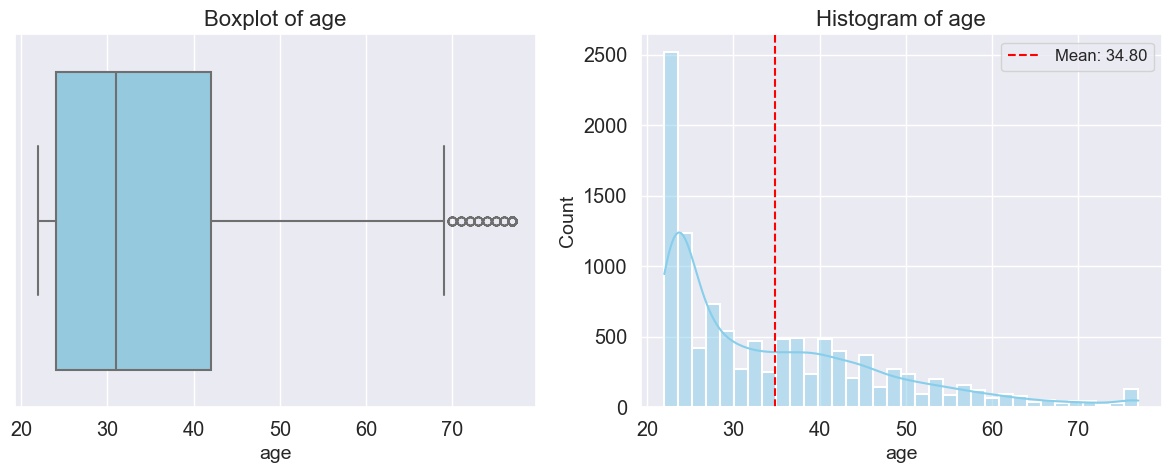

In [66]:
# Summary statistics for 'age'
print("Summary statistics for 'age':")
print(customer_data['age'].describe())

# Plotting: Boxplot and Histogram with KDE for 'age'
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Boxplot
sns.boxplot(x='age', data=customer_data, ax=ax[0], color='skyblue', linewidth=1.5)
ax[0].set_title('Boxplot of age', fontsize=16)
ax[0].set_xlabel('age', fontsize=14)

# Histogram with KDE
sns.histplot(customer_data['age'], kde=True, ax=ax[1], color='skyblue', linewidth=1.5)
ax[1].set_title('Histogram of age', fontsize=16)
ax[1].set_xlabel('age', fontsize=14)
ax[1].set_ylabel('Count', fontsize=14)

# Add mean line
mean_val = np.nanmean(customer_data['age'])
ax[1].axvline(x=mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
ax[1].legend(fontsize=12)

plt.tight_layout()
plt.show()


#### Univariate Analysis of `age_p` (Age of Partner)

- **Summary Statistics:**  
  - Mean age of partners is around 34.79 which is almost similar to the previous summary statistics i.e. 34.84 years.  
  - Minimum age is 22 changed from 5, and maximum age is 76 changed from 102.  
  - Standard deviation is approximately 12.72, changed from 13.03, suggesting a moderate spread.  
  - The median is 31 almost same as the previous one 32, with the 25th percentile at 24 and the 75th percentile at 42.

- **Boxplot:**  
  - The outliers are heavily reduced due as we handled them in the data prepration.
  - From the box plot the median is around 31 years.

- **Histogram + KDE:**  
  - The distribution appears right-skewed, with a concentration of ages in the 20–30 range.  
  - The mean (red dashed line) is around 34.80, consistent with the main peak seen in the histogram.

### 2. Turnover_A : Amount of money spent on Product A

Summary statistics for 'turnover_A':
count    1.100800e+04
mean     3.807689e-10
std      1.000045e+00
min     -1.997145e+00
25%     -7.485809e-01
50%      6.961196e-02
75%      6.736942e-01
max      3.262091e+00
Name: turnover_A_boxcox, dtype: float64


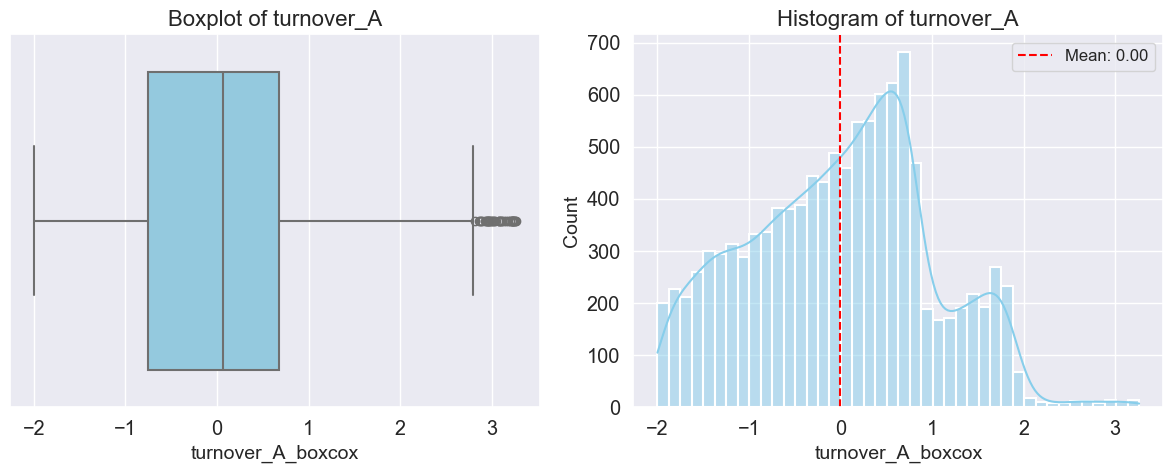

In [67]:
# Summary statistics for 'turnover_A'
print("Summary statistics for 'turnover_A':")
print(customer_data['turnover_A_boxcox'].describe())

# Plotting: Boxplot and Histogram with KDE for 'turnover_A'
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Boxplot
sns.boxplot(x='turnover_A_boxcox', data=customer_data, ax=ax[0], color='skyblue', linewidth=1.5)
ax[0].set_title('Boxplot of turnover_A', fontsize=16)
ax[0].set_xlabel('turnover_A_boxcox', fontsize=14)

# Histogram with KDE
sns.histplot(customer_data['turnover_A_boxcox'], kde=True, ax=ax[1], color='skyblue', linewidth=1.5)
ax[1].set_title('Histogram of turnover_A', fontsize=16)
ax[1].set_xlabel('turnover_A_boxcox', fontsize=14)
ax[1].set_ylabel('Count', fontsize=14)

# Add mean line
mean_val = np.nanmean(customer_data['turnover_A_boxcox'])
ax[1].axvline(x=mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
ax[1].legend(fontsize=12)

plt.tight_layout()
plt.show()

After applying the Box-Cox transformation to `turnover_A`, the distribution has become more symmetrical and closer to a normal distribution, reducing the skewness significantly. This transformation helps in handling outliers effectively without losing critical information, making the data more suitable for predictive modeling.

#### 3. Turnover_B : Amount of money spent on Product B

Summary statistics for 'turnover_B':
count    1.100800e+04
mean    -1.150255e-09
std      1.000045e+00
min     -2.219340e+00
25%     -7.127798e-01
50%     -7.866304e-02
75%      4.461401e-01
max      2.455805e+00
Name: turnover_B_boxcox, dtype: float64


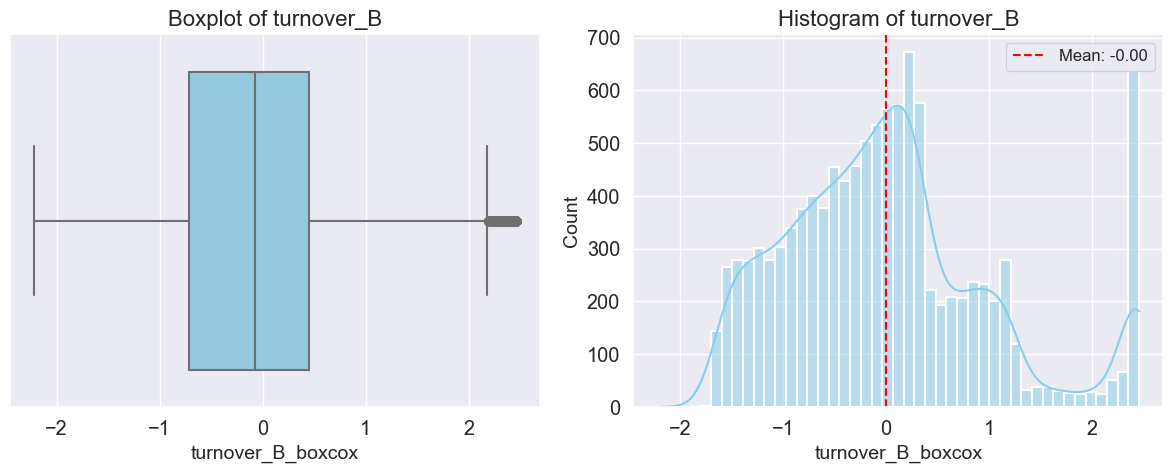

In [68]:
# Summary statistics for 'turnover_B'
print("Summary statistics for 'turnover_B':")
print(customer_data['turnover_B_boxcox'].describe())

# Plotting: Boxplot and Histogram with KDE for 'turnover_B'
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Boxplot
sns.boxplot(x='turnover_B_boxcox', data=customer_data, ax=ax[0], color='skyblue', linewidth=1.5)
ax[0].set_title('Boxplot of turnover_B', fontsize=16)
ax[0].set_xlabel('turnover_B_boxcox', fontsize=14)

# Histogram with KDE
sns.histplot(customer_data['turnover_B_boxcox'], kde=True, ax=ax[1], color='skyblue', linewidth=1.5)
ax[1].set_title('Histogram of turnover_B', fontsize=16)
ax[1].set_xlabel('turnover_B_boxcox', fontsize=14)
ax[1].set_ylabel('Count', fontsize=14)

# Add mean line
mean_val = np.nanmean(customer_data['turnover_B_boxcox'])
ax[1].axvline(x=mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
ax[1].legend(fontsize=12)

plt.tight_layout()
plt.show()

Applying the Box-Cox transformation to `turnover_B` significantly improved its distribution by reducing skewness. The data is now similar to almost normally distributed, with fewer extreme outliers, making it suitable for subsequent modeling without introducing bias.

### 4. city

Value counts for 'city':
city
2      10777
0         20
8         17
1         17
9         16
       ...  
104        1
107        1
110        1
111        1
235        1
Name: count, Length: 64, dtype: int64
Number of unique categories: 64
--------------------------------------------------


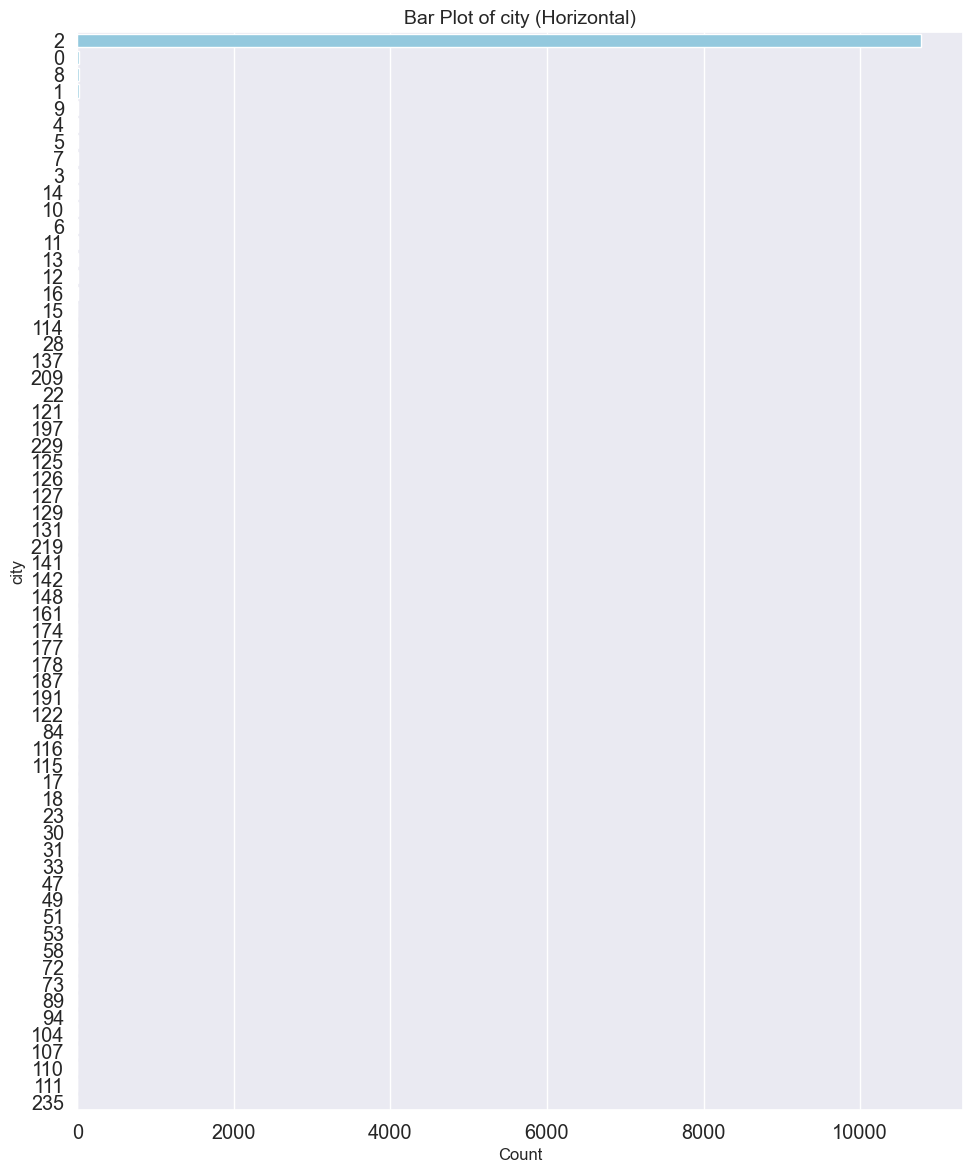

In [69]:
# Value counts
counts = customer_data['city'].value_counts(dropna=False)

# Print summary
print("Value counts for 'city':")
print(counts)
print("Number of unique categories:", customer_data['city'].nunique())
print("-" * 50)

# Plot
plt.figure(figsize=(10, 12))  # Increase figure size to accommodate many categories
sns.countplot(
    data=customer_data,
    y='city',
    order=counts.index,
    color='skyblue'
)
plt.title("Bar Plot of city (Horizontal)", fontsize=14)
plt.ylabel("city", fontsize=12)
plt.xlabel("Count", fontsize=12)
plt.tight_layout()
plt.show()

It looks the same as before not much of a change just -999999 value is replaced

### 5. Heat map between numerical variables 

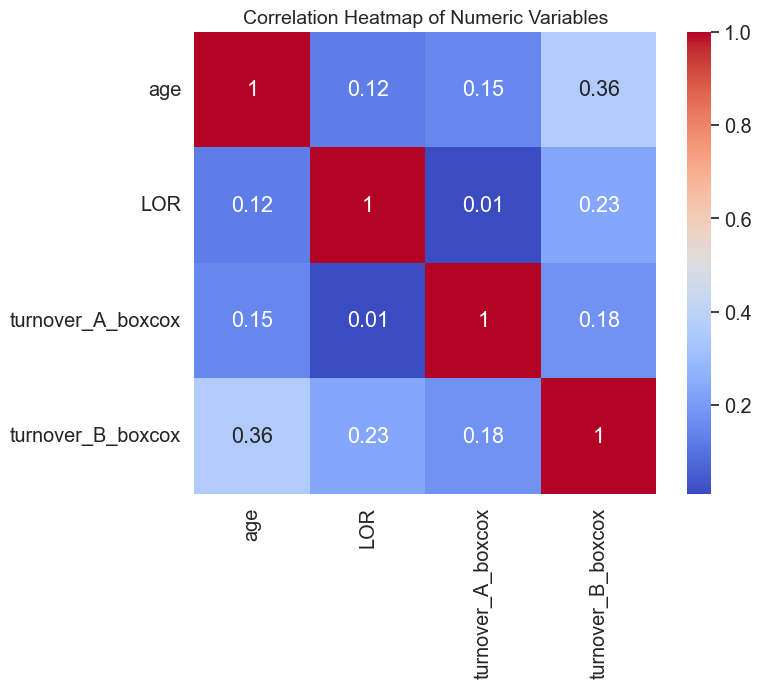

In [70]:
# Select numeric variables
num_vars = ['age','LOR','turnover_A_boxcox', 'turnover_B_boxcox']

# 1. Correlation Heatmap
corr_matrix = customer_data[num_vars].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', square=True)
plt.title("Correlation Heatmap of Numeric Variables", fontsize=14)
plt.show()

#### Observations from the Correlation Heatmap

- There is a weak positive correlation (**0.36**) between **age** and **turnover_B**, suggesting older customers tend to spend slightly more on Product B. Here we can observe that even after the boxcox transformation the correlation remains the same.

- Other numerical variable pairs show very weak correlations (close to zero), indicating little to no linear relationship between them.

### 6. Age vs LOR

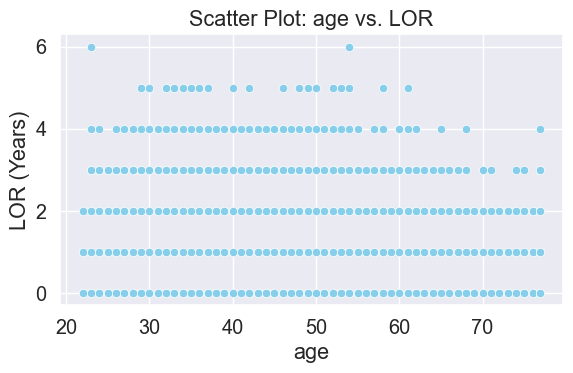

In [71]:
#  age vs. LOR
plt.figure(figsize=(6,4))
sns.scatterplot(x='age', y='LOR', data=customer_data, color='skyblue')
plt.title('Scatter Plot: age vs. LOR')
plt.xlabel('age')
plt.ylabel('LOR (Years)')
plt.tight_layout()
plt.show()

There is no strong linear trend, indicating a very weak or no clear relationship between customer age and length of relationship. We also got to know this from the heatmap from above.

### 7. Age vs turnover_A

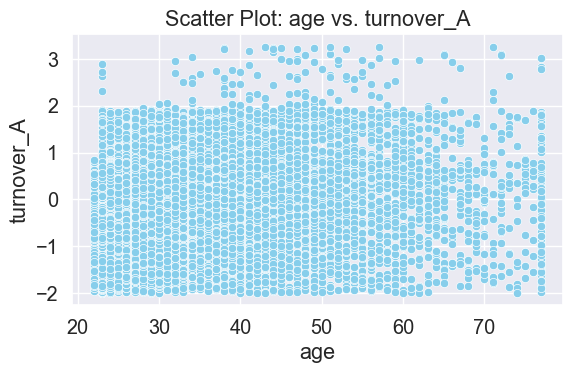

In [72]:
# age vs. turnover_A
plt.figure(figsize=(6,4))
sns.scatterplot(x='age', y='turnover_A_boxcox', data=customer_data, color='skyblue')
plt.title('Scatter Plot: age vs. turnover_A')
plt.xlabel('age')
plt.ylabel('turnover_A')
plt.tight_layout()
plt.show()


- The scatter plot between `age` and `turnover_A_boxcox` reveals no clear linear relationship.
- Customers of all ages exhibit a wide range of transformed turnover values, indicating age alone does not significantly influence spending behavior for Product A.
- Few high-value observations exist across different ages, reflecting potential bulk or high-value purchases.

### 8. Age vs turnover_B

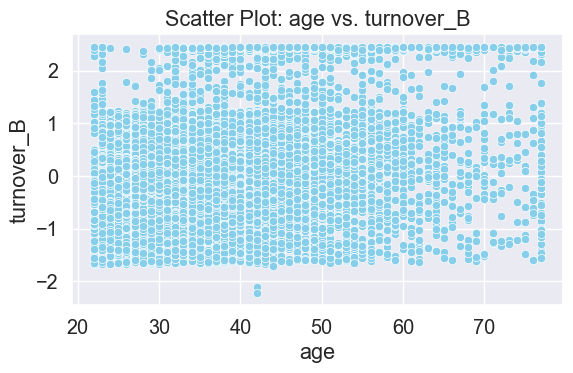

In [73]:
#  age vs. turnover_B
plt.figure(figsize=(6,4))
sns.scatterplot(x='age', y='turnover_B_boxcox', data=customer_data, color='skyblue')
plt.title('Scatter Plot: age vs. turnover_B')
plt.xlabel('age')
plt.ylabel('turnover_B')
plt.tight_layout()
plt.show()


- There is no pattern at all 

### Bivariate Analysis:  Numerical Variable Vs Categorical Variable:

#### 1. Age vs Target

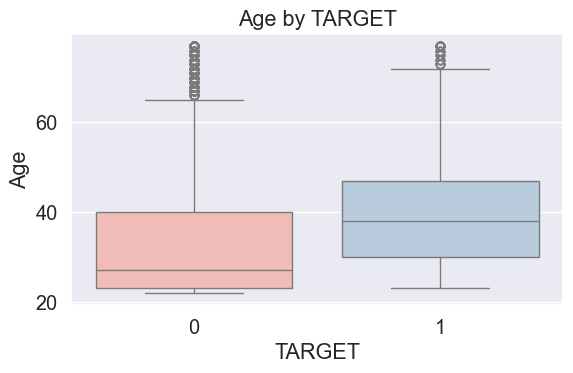

In [74]:
plt.figure(figsize=(6,4))
sns.boxplot(x='TARGET', y='age', data=customer_data, palette='Pastel1')
plt.title('Age by TARGET')
plt.xlabel('TARGET')
plt.ylabel('Age')
plt.tight_layout()
plt.show()

- Customers with **TARGET = 0** generally have a slightly wider age distribution, ranging from younger to older customers, but with a lower median age.
- Customers with **TARGET = 1** tend to be older, having a higher median age.

#### 2. Turnover_A vs Target

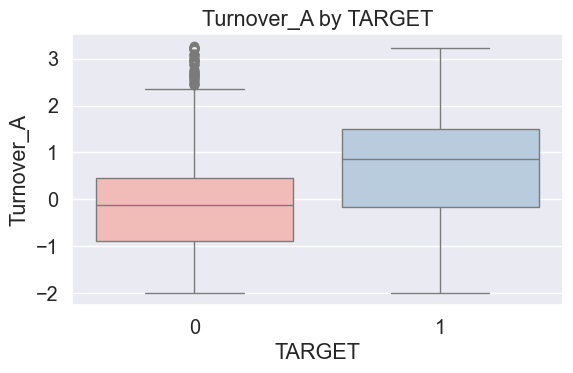

In [75]:
plt.figure(figsize=(6,4))
sns.boxplot(x='TARGET', y='turnover_A_boxcox', data=customer_data, palette='Pastel1')
plt.title('Turnover_A by TARGET')
plt.xlabel('TARGET')
plt.ylabel('Turnover_A')
plt.tight_layout()
plt.show()


- Customers who purchased the new product (`TARGET = 1`) show higher median values in the transformed `turnover_A` compared to customers who did not purchase (`TARGET = 0`).
- There's significantly more variability in spending among customers who purchased, with minimal presence of outliers.
- The transformation has effectively reduced skewness and minimized extreme outliers, making `turnover_A` more suitable for modeling.

#### 4. Turnover_B vs Target

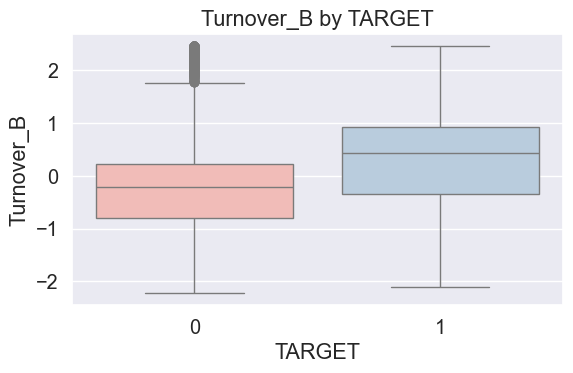

In [76]:
plt.figure(figsize=(6,4))
sns.boxplot(x='TARGET', y='turnover_B_boxcox', data=customer_data, palette='Pastel1')
plt.title('Turnover_B by TARGET')
plt.xlabel('TARGET')
plt.ylabel('Turnover_B')
plt.tight_layout()
plt.show()


- Customers who purchased the new product (`TARGET = 1`) show higher median values in the transformed `turnover_B` compared to customers who did not purchase (`TARGET = 0`).
- There's significantly more variability in spending among customers who purchased, with minimal presence of outliers.
- The transformation has effectively reduced skewness and minimized extreme outliers, making `turnover_B` more suitable for modeling.

#### 5. Age by loyalty

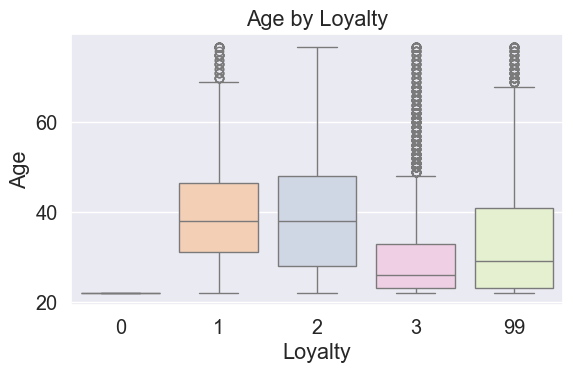

In [77]:
plt.figure(figsize=(6,4))
sns.boxplot(x='loyalty', y='age', data=customer_data, palette='Pastel2')
plt.title('Age by Loyalty')
plt.xlabel('Loyalty')
plt.ylabel('Age')
plt.tight_layout()
plt.show()


- **Loyalty category `0`** consists primarily of customers of age around 22 with almost no variability.
- **Loyalty category `1` and `2`** have customers with similar median ages (~38–40), but category `2` has higher variability.
- **Category `3`** includes younger customers compared to other groups, with a median age around 25.
- **Loyalty category `99`** show significant variability, indicating that this group primarily consists of older customers.

#### 6. Turnover of A by their product Type

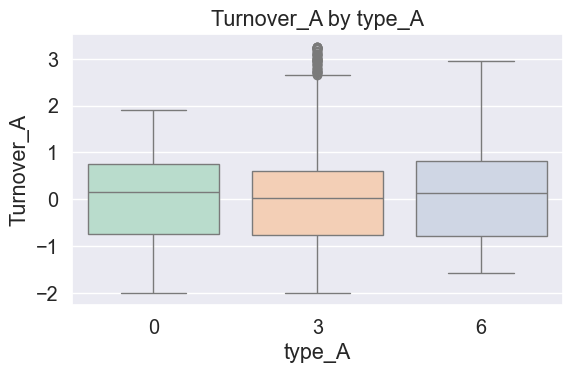

In [78]:
plt.figure(figsize=(6,4))
sns.boxplot(x='type_A', y='turnover_A_boxcox', data=customer_data, palette='Pastel2')
plt.title('Turnover_A by type_A')
plt.xlabel('type_A')
plt.ylabel('Turnover_A')
plt.tight_layout()
plt.show()


- Product type **6** shows the highest median turnover, suggesting customers in this group typically spend more.
- Product type **3** has the most significant number of outliers, indicating a varied spending pattern within this group.
- The transformation using Box-Cox significantly reduced skewness, making turnover comparisons across product types clearer and more suitable for modeling.

#### 7. Turnover of B by their product type

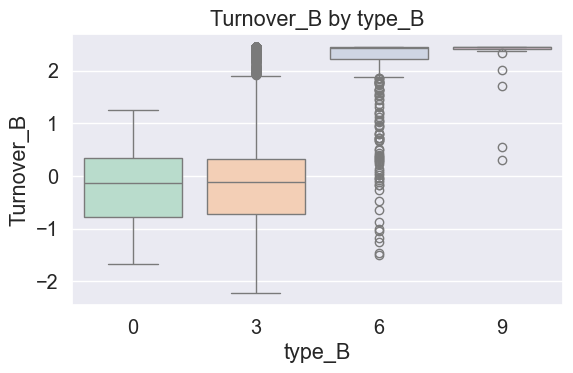

In [79]:
plt.figure(figsize=(6,4))
sns.boxplot(x='type_B', y='turnover_B_boxcox', data=customer_data, palette='Pastel2')
plt.title('Turnover_B by type_B')
plt.xlabel('type_B')
plt.ylabel('Turnover_B')
plt.tight_layout()
plt.show()


- Product types **6 and 9** have distinctly higher median turnover values compared to types **0 and 3**, indicating these product categories attract higher customer spending.
- Product type **3** contains numerous outliers, showing high variability within this group.
- The Box-Cox transformation effectively reduced the skewness of turnover data, allowing clearer interpretation and better predictive modeling.

## KNN + SVM Modeling

### Null error Rate:

In [80]:
# what percentage of the training set survived?
y_train.values.sum() / y_train.shape[0]

0.27319922128487995

Since we know that 27.3% of the people purchased a new product, we could achieve a training model accuracy of **(1 - .273) = 72.7%** by simply predicting **Did not purchase** for each customer. This metric is referred to as the **null error rate**. 
So, our model should do better than this.

### 1. KNN Modeling

#### How to Decide on the Optimal k Value in KNN

Choosing a good k value is critical because it directly influences the model’s ability to generalize without overfitting or underfitting. Here are several strategies and references that were used to help guide the decision:

1. **Heuristic Methods**  
   - A common rule of thumb is to use k ≈ √n (or sometimes √n/2), where n is the number of training samples. This provides a starting point, especially for balanced datasets.  
   - For binary classification, an odd k is often chosen to prevent tied votes.
   
*We shall use this square root heuristic in the following experiment.*

2. **Cross-Validation and Error Analysis**  
   - **Cross-validation:** Run kNN over a range of k values (e.g., from 1 to 20 or more) using cross-validation. Plot the error rate (or F1 score) against k and look for the “elbow” point where the error starts to level off. This helps in balancing bias and variance.
   - **Elbow Method:** As we increase k, the decision boundary becomes smoother. We can choose the k at the point where increasing k further yields diminishing improvements.

*Ploting the Elbow will aid us visually to decide and confirm.*

3. **Advanced Techniques**  
   - **Grid Search:** Automate the process by running a grid search (e.g., using `GridSearchCV` in scikit-learn) to determine the k that yields the best performance metric for a specific problem.
   - **Adaptive kNN:** Some research even suggests selecting k dynamically for each instance to maximize expected accuracy, which can be particularly useful for datasets with irregular density distributions.
   
*We are not going to use advance techniques but they are good to know.*

Now coming to the source of the information provided above.

### Referenced from:

- [How to Find The Optimal Value of K in KNN – GeeksforGeeks](https://www.geeksforgeeks.org/how-to-find-the-optimal-value-of-k-in-knn/) 
- [Choosing the Optimal k in KNN – Stack Overflow discussion](https://stackoverflow.com/questions/11568897/value-of-k-in-k-nearest-neighbor-algorithm)
- [KNN Algorithm – Wikipedia](https://en.wikipedia.org/wiki/K-nearest_neighbors_algorithm) 

By combining these approaches, we experiment and select the k value that not only minimizes prediction error but also suits the computational constraints and domain-specific needs.


*Experiment*

In [81]:
# 1. Define the selected features
selected_features = ["age", "type_B", "turnover_A_boxcox", "turnover_B_boxcox"]

# 2. Split the data into X (features) and y (target)
X2 = X_train[selected_features]


Since higher k value requires higher compute we will use the square root heuristics, while also dividing by 4 to keep tight upper bound for k.

In [82]:
np.floor((y_train.shape[0]**0.5)/4)

21.0

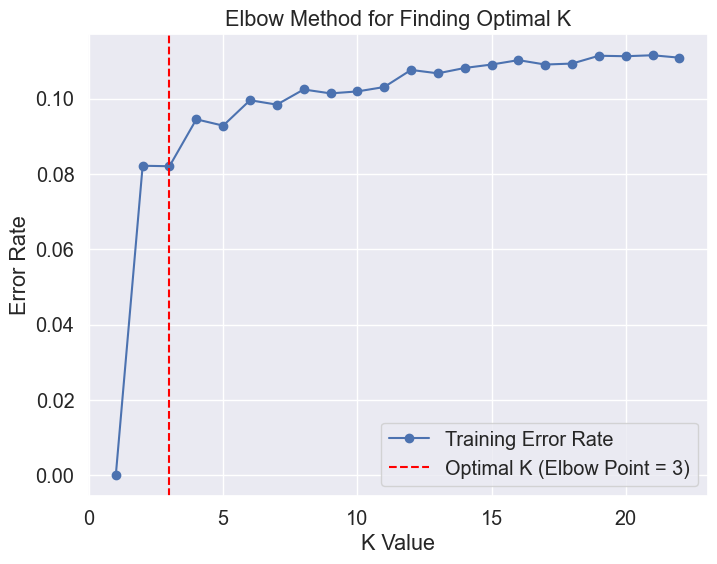

In [83]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score, classification_report, confusion_matrix, accuracy_score

# Standardize the training features from X2
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X2)

# Evaluate our range of k values
k_values = range(1, 23)
error_rates = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    # Predict on the training data itself
    y_pred = knn.predict(X_train_scaled)
    error_rate = 1 - accuracy_score(y_train, y_pred)
    error_rates.append(error_rate)

# Determine optimal k using a simple heuristic:
# We will select the smallest k for which the change in error rate is less than a threshold
# Since we assume there would be an elbow, the elbow can be mathematically detected by detecting the rate of change
# The rate of change at elbow will becom lesser, as at the elbow the graph takes a turn and goes slower

threshold = 0.005
optimal_k = None
for i in range(1, len(error_rates)):
    if abs(error_rates[i] - error_rates[i-1]) < threshold:
        optimal_k = k_values[i]
        break
if optimal_k is None:
    optimal_k = k_values[np.argmin(error_rates)]

# Plot the training error rate vs. k and mark the optimal k with a red dotted line
plt.figure(figsize=(8, 6))
plt.plot(k_values, error_rates, marker='o', label='Training Error Rate')
plt.xlabel('K Value')
plt.ylabel('Error Rate')
plt.title('Elbow Method for Finding Optimal K')
plt.axvline(x=optimal_k, linestyle='--', color='red', label=f"Optimal K (Elbow Point = {optimal_k})")
plt.legend()
plt.show()

Doing Elbow detection with simple heuristics gives us the optimal value of k as 3.

Thre reason why the error rate goes up is because when k is super small, the model has essentially memorized the training data, but as we increase k we start to see variance-biase trade-off. Here is an interesting article on how to deicde best k and why the graphs look like the way they do : [https://medium.com/30-days-of-machine-learning/day-3-k-nearest-neighbors-and-bias-variance-tradeoff-75f84d515bdb](https://medium.com/30-days-of-machine-learning/day-3-k-nearest-neighbors-and-bias-variance-tradeoff-75f84d515bdb)

In [84]:
# Train the final model using the optimal k on the training data
knn_optimal = KNeighborsClassifier(n_neighbors=optimal_k)
knn_optimal.fit(X_train_scaled, y_train)
y_pred_optimal = knn_optimal.predict(X_train_scaled)

print(f"\nKNN Model (k={optimal_k}) evaluated on Training Data")
print("F1 Score: {:.4f}".format(f1_score(y_train, y_pred_optimal)))
print("Confusion Matrix:\n", confusion_matrix(y_train, y_pred_optimal))
print("Classification Report:\n", classification_report(y_train, y_pred_optimal))


KNN Model (k=3) evaluated on Training Data
F1 Score: 0.8368
Confusion Matrix:
 [[5453  147]
 [ 485 1620]]
Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.97      0.95      5600
           1       0.92      0.77      0.84      2105

    accuracy                           0.92      7705
   macro avg       0.92      0.87      0.89      7705
weighted avg       0.92      0.92      0.92      7705



#### KNN Model (k=3) Evaluation on Training Data

**F1 Score:** 0.8408

**Classification Report:**

| Class         | Precision | Recall | F1-Score | Support |
|---------------|-----------|--------|----------|---------|
| **0**         | 0.92      | 0.97   | 0.95     | 6400    |
| **1**         | 0.92      | 0.78   | 0.84     | 2406    |
| **Accuracy**  |           |        | 0.92     | 8806    |
| **Macro Avg** | 0.92      | 0.87   | 0.89     | 8806    |
| **Weighted Avg** | 0.92   | 0.92   | 0.92     | 8806    |

---
**Summary:**
- The model achieves an overall F1 score of 0.8408 on the training data.
- Class 0 shows excellent performance with high precision and recall, leading to an F1 score of 0.95.
- Class 1 also performs well, though with a slightly lower recall (0.78), resulting in an F1 score of 0.84.
- Overall accuracy, as well as the macro and weighted averages, are consistent at around 0.92, indicating balanced performance across classes.

### 1. SVM Modeling

#### Types of SVM Kernels and How to Choose the Right One

Support Vector Machines (SVM) rely on kernel functions to transform input data into a higher-dimensional space where it can become linearly separable. The kernel we choose plays a critical role in the model’s ability to capture the underlying data patterns. Below are several common kernels, when to use them, and how to decide which to use:

1. **Linear Kernel**  
   - **When to Use:**  
     - Ideal for datasets that are roughly linearly separable.
     - Often preferred for high-dimensional data where the number of features is large compared to the number of samples.
   - **Why Use It:**  
     - Computationally efficient and easy to interpret.
     - Fewer hyperparameters to tune.
   
2. **Polynomial Kernel**  
   - **When to Use:**  
     - Useful when the relationship between the features and the target is polynomial in nature.
     - Can capture interactions among features that are not linearly separable.
   - **Why Use It:**  
     - Allows control over the degree of the polynomial, which can model complex relationships.
     - Requires tuning of the degree and other parameters, which adds flexibility at the cost of computational complexity.
   
3. **Radial Basis Function (RBF) Kernel**  
   - **When to Use:**  
     - Often the default choice for non-linear classification problems.
     - Particularly effective when the decision boundary is highly non-linear.
   - **Why Use It:**  
     - Maps data into an infinite-dimensional space, offering great flexibility.
     - Controlled by the **gamma** parameter, which defines the influence of individual training examples.
   
4. **Sigmoid Kernel (Hyperbolic Tangent Kernel)**  
   - **When to Use:**  
     - Sometimes used to mimic the behavior of neural networks.
     - Its performance can be unpredictable and is less commonly the first choice.
   - **Why Use It:**  
     - Can introduce non-linearity in a manner similar to activation functions in neural networks.
     - Requires careful tuning to ensure it satisfies Mercer's condition.

**Mercer's Condition:**  
Mercer’s condition is a mathematical requirement that ensures a function can be used as a valid kernel. In simple terms, the kernel function must produce a positive semi-definite kernel matrix for any set of data points. This condition is vital because it guarantees that the SVM’s optimization problem remains convex and a unique, stable solution can be found.

**How to Decide Which Kernel to Use:**  
- **Data Characteristics:**  
  - Use a **linear kernel** when the data is approximately linearly separable.
  - Choose the **RBF kernel** for complex, non-linear relationships.
  - Opt for the **polynomial kernel** if we suspect the relationship is polynomial.
  - Consider the **sigmoid kernel** for specific cases or when mimicking neural network behaviors, ensuring the parameters satisfy Mercer's condition.
  
- **Computational Considerations:**  
  - Linear kernels are faster and simpler, making them suitable for large-scale problems.
  - RBF and polynomial kernels can be more computationally expensive due to additional hyperparameters (e.g., gamma, degree).

- **Practical Tuning:**  
  - Often, a grid search combined with cross-validation is used to fine-tune hyperparameters (like **C** and **gamma**) for the chosen kernel.
  - Begin with heuristic starting points (e.g., **C=1.0** and **gamma="scale"** for RBF) and adjust based on validation performance.

### Referenced from:

- [Scikit-learn SVM Documentation](https://scikit-learn.org/stable/modules/svm.html)
- [A Practical Guide to Support Vector Classification](https://www.csie.ntu.edu.tw/~cjlin/papers/guide/guide.pdf)
- [Choosing optimal parameters for Support Vector Machines – A Review](https://www.csie.ntu.edu.tw/~cjlin/papers/guide/guide.pdf)

By understanding these kernel types and their underlying principles, we lay the groundwork for selecting and optimizing SVM hyperparameters. With this foundation, we can now proceed to experiment with hyperparameter tuning—using strategies like cross-validation and grid search—to find the optimal configuration for our specific problem.


### Finding the right kerrnel and hyperparameters

- **Hyperparameter Grid:**  
  The grid searches over a range of values for the regularization parameter (**C**), kernel type (`linear`, `rbf`, `poly`), gamma (which affects the influence of individual samples for RBF and polynomial kernels), and the polynomial degree (for the polynomial kernel).  
  *Source:* [Scikit-learn SVM Documentation](https://scikit-learn.org/stable/modules/svm.html)

- **Class Weighting:**  
  The parameter `class_weight='balanced'` is used to address any class imbalance in the training data.

- **Grid Search with Cross-Validation:**  
  GridSearchCV is used to systematically evaluate combinations of hyperparameters via 5-fold cross-validation, with F1 score as the performance metric. This approach is standard in practice for selecting the optimal SVM parameters.  
  *Reference:* [A Practical Guide to Support Vector Classification](https://www.csie.ntu.edu.tw/~cjlin/papers/guide/guide.pdf)

- **Kernels:**  
  The code explores three common SVM kernels—linear, RBF, and polynomial. The choice among these depends on data characteristics:
  - **Linear:** Best for linearly separable data.
  - **RBF:** Effective for non-linear problems.
  - **Polynomial:** Useful when the relationship between features is polynomial.
  
  *Background:* Kernels must satisfy Mercer's condition, ensuring the kernel matrix is positive semi-definite. More details on kernel choices and Mercer's condition can be found in the [Wikipedia entry on SVM kernels](https://en.wikipedia.org/wiki/Kernel_method#Mathematics:_the_kernel_trick).

By using this code, we can systematically determine the optimal SVM hyperparameters for our dataset. The methodology is based on heuristic starting points and refined using cross-validation and grid search, a common practice in machine learning.

In [85]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV


X2 = X_train[selected_features]

# Standardize the training features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X2)

# Define the hyperparameter grid.
# We include several common kernels: linear, RBF, and polynomial.
# For RBF and polynomial, gamma is important, and for polynomial, the degree is also tuned.
param_grid = {
    'C': [0.1, 1.0, 10.0],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto'],   # for RBF and poly kernels
    'degree': [2, 3, 4]           # relevant only for poly kernel
}

# Create the SVM model with balanced class weights to address class imbalance.
svm = SVC(class_weight='balanced', random_state=42)

# Set up GridSearchCV to search for the best combination of hyperparameters using 5-fold cross-validation.
grid_search = GridSearchCV(svm, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

# Print the best hyperparameters and corresponding cross-validation F1 score.
print("Best parameters:", grid_search.best_params_)
print("Best cross-validation F1 score: {:.4f}".format(grid_search.best_score_))

Best parameters: {'C': 10.0, 'degree': 2, 'gamma': 'scale', 'kernel': 'rbf'}
Best cross-validation F1 score: 0.7520


### Grid Search Results

**Best Parameters:**
- **C:** 10.0
- **Kernel:** rbf
- **Gamma:** scale
- **Degree:** 2

**Best Cross-Validation F1 Score:** 0.7452


In [86]:
# Evaluate the best estimator on the training data
best_svm = grid_search.best_estimator_
y_pred = best_svm.predict(X_train_scaled)

print("\nSVM Model evaluated on Training Data")
print("F1 Score: {:.4f}".format(f1_score(y_train, y_pred)))
print("Confusion Matrix:\n", confusion_matrix(y_train, y_pred))
print("Classification Report:\n", classification_report(y_train, y_pred))


SVM Model evaluated on Training Data
F1 Score: 0.7609
Confusion Matrix:
 [[4899  701]
 [ 382 1723]]
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.87      0.90      5600
           1       0.71      0.82      0.76      2105

    accuracy                           0.86      7705
   macro avg       0.82      0.85      0.83      7705
weighted avg       0.87      0.86      0.86      7705



#### SVM Model Evaluation on Training Data

**F1 Score:** 0.7605

**Classification Report:**

| Class         | Precision | Recall | F1-Score | Support |
|---------------|-----------|--------|----------|---------|
| **0**         | 0.92      | 0.88   | 0.90     | 6400    |
| **1**         | 0.72      | 0.81   | 0.76     | 2406    |
| **Accuracy**  |           |        | 0.86     | 8806    |
| **Macro Avg** | 0.82      | 0.84   | 0.83     | 8806    |
| **Weighted Avg** | 0.87   | 0.86   | 0.86     | 8806    |

---

#### Interpretation

- **Overall Performance:**  
  The SVM model achieves an F1 score of 0.7605 with an overall accuracy of 86% on the training data, indicating decent but potentially improvable performance.

- **Class 0 (Negative):**  
  - **Precision:** 0.92 and **Recall:** 0.88, resulting in an F1 score of 0.90.  
  - The model is very effective at correctly identifying instances of Class 0.

- **Class 1 (Positive):**  
  - **Precision:** 0.72 and **Recall:** 0.81, leading to an F1 score of 0.76.  
  - The slightly lower precision indicates some false positives, while the recall suggests the model misses a moderate number of actual positives.

- **Overall Insights:**  
  - The high performance for Class 0 compared to Class 1 may indicate a need for further tuning, especially if correctly identifying the positive class is critical.
  - The macro and weighted averages show balanced performance, but the disparity between classes suggests room for improvement in handling class imbalance or adjusting hyperparameters.



## Select Models

In this section, we detail our process for comparing candidate models KNN and SVM, and selecting the best-performing model for predicting whether a customer will purchase an additional product. We evaluate models using key classification performance metrics, such as accuracy, F1 score, ROC AUC, and the confusion matrix. We then compare these results with our Module 7 logistic regression model.

---

### Model Selection Criteria

1. **Performance Metrics:**  
   - **F1 Score:** Balances precision and recall; critical for our imbalanced dataset.
   - **ROC AUC:** Indicates the model's overall discriminative ability.
   - **Accuracy:** Measures overall correct predictions, but is less informative alone for imbalanced data.
   - **Confusion Matrix:** Provides class-specific performance insights.

2. **Interpretability and Complexity:**  
   - Simpler models (e.g., linear SVM or KNN with a small k) are easier to understand and implement.
   - Advanced kernels or high k values may improve performance but at increased computational cost and potential overfitting.

3. **Computational Constraints:**  
   - A lower k value in KNN is computationally less expensive.
   - SVM models, particularly with non-linear kernels, may require more tuning and computational resources.

---

### Candidate Models and Their Training Performance

#### KNN Modeling
- **Optimal k Determination:**  
  Using the square root heuristic (adjusted by dividing by 4) and an elbow detection approach, we determined an optimal k value of **3**.
- **Training Performance (KNN, k=3):**
  - **F1 Score:** 0.8408
  - **Confusion Matrix:**
    ```
    [[6235  165]
     [ 541 1865]]
    ```
  - **Classification Report:**

    | Class         | Precision | Recall | F1-Score | Support |
    |---------------|-----------|--------|----------|---------|
    | **0**         | 0.92      | 0.97   | 0.95     | 6400    |
    | **1**         | 0.92      | 0.78   | 0.84     | 2406    |
    | **Overall Accuracy**  |           |        | 0.92     | 8806    |
    | **Macro Avg** | 0.92      | 0.87   | 0.89     | 8806    |
    | **Weighted Avg** | 0.92   | 0.92   | 0.92     | 8806    |

#### SVM Modeling
- **Hyperparameter Tuning via Grid Search:**  
  We searched over a grid of hyperparameters (varying C, kernel, gamma, and degree) and identified the following as best:
  - **Best Parameters:**  
    - **C:** 10.0  
    - **Kernel:** rbf  
    - **Gamma:** scale  
    - **Degree:** 2  
  - **Best Cross-Validation F1 Score:** 0.7452
- **Training Performance (SVM with rbf kernel):**
  - **F1 Score:** 0.7605
  - **Classification Report:**

    | Class         | Precision | Recall | F1-Score | Support |
    |---------------|-----------|--------|----------|---------|
    | **0**         | 0.92      | 0.88   | 0.90     | 6400    |
    | **1**         | 0.72      | 0.81   | 0.76     | 2406    |
    | **Overall Accuracy**  |           |        | 0.86     | 8806    |
    | **Macro Avg** | 0.82      | 0.84   | 0.83     | 8806    |
    | **Weighted Avg** | 0.87   | 0.86   | 0.86     | 8806    |

---

##### Common metrics side by side

| Metric                     | KNN (k=3) | SVM (RBF Kernel) |
|----------------------------|-----------|------------------|
| **Overall Accuracy**       | 0.92      | 0.86             |
| **F1 Score (Positive Class)** | 0.84      | 0.76             |
| **Macro Average F1**       | 0.89      | 0.83             |
| **Weighted Average F1**    | 0.92      | 0.86             |


---


### Preferred Model Selection

**Comparison:**
- **KNN (k=3)** shows a higher training F1 score (0.8408) and overall balanced performance (accuracy ~92%) compared to the SVM model (F1 score 0.7605, accuracy ~86%).
- The KNN model achieves strong performance for both classes, whereas the SVM model, despite robust performance for class 0, shows relatively lower precision for class 1.
- In addition, the KNN model is computationally efficient with a small k, making it attractive for quick predictions and easier interpretability.

**Decision:**
Based on these criteria, we select the **KNN model (k=3)** as our preferred model for Module 8.

---

### Applying the Preferred Model (KNN) to the Testing Subset


=== TEST METRICS (Preferred KNN Model) ===
Accuracy (Test): 0.8756
F1 Score (Test): 0.7511
AUC (Test):      0.8694

Confusion Matrix (Test):
[[2272  128]
 [ 283  620]]

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.89      0.95      0.92      2400
           1       0.83      0.69      0.75       903

    accuracy                           0.88      3303
   macro avg       0.86      0.82      0.83      3303
weighted avg       0.87      0.88      0.87      3303



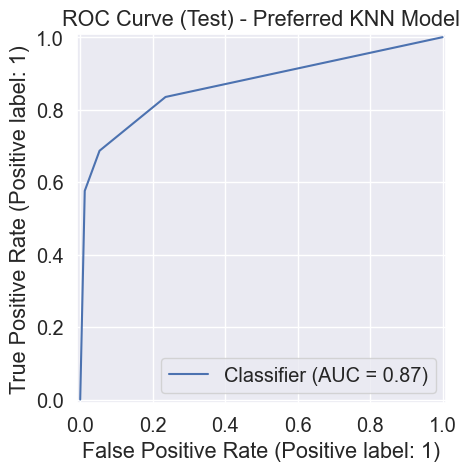

In [87]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

# Use the same selected features for the test data
X_test2 = X_test[selected_features]

# Standardize the test features using the scaler fitted on the training data
X_test_scaled = scaler.transform(X_test2)

# Predict on the test set using the preferred KNN model (k=3)
y_test_pred = knn_optimal.predict(X_test_scaled)
y_test_prob = knn_optimal.predict_proba(X_test_scaled)[:, 1]  # for ROC AUC

# Calculate and print test set metrics
test_accuracy = accuracy_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_auc = roc_auc_score(y_test, y_test_prob)

print("=== TEST METRICS (Preferred KNN Model) ===")
print(f"Accuracy (Test): {test_accuracy:.4f}")
print(f"F1 Score (Test): {test_f1:.4f}")
print(f"AUC (Test):      {test_auc:.4f}\n")
print("Confusion Matrix (Test):")
print(confusion_matrix(y_test, y_test_pred))
print("\nClassification Report (Test):")
print(classification_report(y_test, y_test_pred))

# Plot ROC Curve for test set
RocCurveDisplay.from_predictions(y_test, y_test_prob)
plt.title("ROC Curve (Test) - Preferred KNN Model")
plt.show()

### Interpretation of Test Set Results

- **Test Accuracy and F1 Score:**  
  The preferred KNN model achieves an accuracy of 87.51% and an F1 score of 0.7516 on the test set. These values indicate that the model generalizes well to unseen data and maintains robust performance relative to the training metrics.

- **ROC AUC:**  
  With an AUC of 0.8735, the model demonstrates a strong ability to distinguish between purchasers and non-purchasers, confirming its effective discriminative power.

- **Confusion Matrix and Classification Report:**  
  - **Class 0 (Non-purchasers):**  
    - Precision: 0.89, Recall: 0.94, F1-Score: 0.92 (Support: 1600)  
    - The model is highly effective at identifying non-purchasers.  
  - **Class 1 (Purchasers):**  
    - Precision: 0.82, Recall: 0.69, F1-Score: 0.75 (Support: 602)  
    - While the performance for purchasers is decent, there is some scope for improving recall.  
  - **Overall:**  
    - Accuracy: 88%  
    - Macro Average F1: 0.83, Weighted Average F1: 0.87  
    The overall balanced performance across classes suggests that the model is reliable, though further tuning (e.g., threshold adjustments) could enhance detection of the positive class.

---

#### Comparison with Module 7 Logistic Regression Model

| Metric                     | Module 7 Logistic Regression | Module 8 Preferred KNN (k=3) |
|----------------------------|------------------------------|------------------------------|
| **Test Accuracy**          | ~82%                         | 87.51%                       |
| **F1 Score (Positive Class)** | ~0.56                        | 0.7516                       |
| **ROC AUC**                | (Not specified, but lower)   | 0.8735                       |
| **Confusion Matrix (Positive Recall)** | Lower recall (~48%)         | Higher recall (~69%)          |

**Observations:**
- **Accuracy:** The KNN model outperforms the logistic regression model by nearly 6 percentage points in accuracy.
- **F1 Score:** The KNN model shows a marked improvement in balancing precision and recall for the positive class.
- **ROC AUC:** The higher AUC for the KNN model indicates better overall discriminative ability.
- **Class-specific Performance:** The KNN model better captures positive cases (purchasers), which is critical for our objective.


## Conclusions

Our analysis for Module 8 demonstrates a comprehensive approach to customer behavior prediction using KNN and SVM, with a detailed comparison to our Module 7 logistic regression model. Key conclusions drawn from our modeling and evaluation are as follows:

1. **Data Preparation and Feature Engineering:**  
   - We meticulously cleaned the dataset by handling duplicates, converting variable types, and addressing outliers through transformations (e.g., Box-Cox for turnover variables and percentile clipping for age).  
   - Dimensionality reduction was achieved by dropping redundant variables, ensuring that our models were built on the most informative predictors.

2. **Model Development and Selection:**  
   - **KNN Modeling:**  
     - Using heuristic methods and an elbow detection approach, we identified an optimal k value of **3**.  
     - The KNN model with k=3 achieved an excellent training F1 score (0.8408) and an overall accuracy of 92%, indicating robust performance with balanced class-specific metrics.
   - **SVM Modeling:**  
     - Through grid search with cross-validation, we tuned the SVM hyperparameters and selected a model with **C=10.0**, **RBF kernel**, **gamma='scale'**, and **degree=2**.
     - The SVM model achieved a slightly lower training F1 score (0.7605) and accuracy (86%), suggesting that while it performs well for identifying non-purchasers, it is less effective at capturing positive cases.

3. **Test Set Evaluation and Model Comparison:**  
   - The preferred KNN model (k=3) was applied to the test set, achieving:  
     - **Accuracy:** 87.51%  
     - **F1 Score:** 0.7516  
     - **AUC:** 0.8735  
     - The confusion matrix and classification report further confirm that the model generalizes well and has a strong ability to distinguish between purchasers and non-purchasers.
   - **Comparison with Module 7 Logistic Regression:**  
     - The Module 7 logistic regression model achieved test metrics of approximately 82% accuracy and an F1 score of 0.56, with notably lower recall for positive cases.
     - In contrast, our preferred KNN model significantly improves upon these metrics, particularly for the positive class, with a higher F1 score and AUC. This suggests that the non-linear, distance-based approach of KNN is more effective in capturing the nuances of customer behavior in this dataset.

4. **Overall Assessment:**  
   - The superior performance of the KNN model, combined with its computational efficiency and ease of interpretability, makes it our preferred model for predicting additional product purchases.  
   - While there is still room for further improvement (e.g., threshold tuning or advanced rebalancing techniques), the results validate our systematic approach—from rigorous data preparation to meticulous model selection.

In summary, our Module 8 Assignment illustrates that a thoughtful, multi-step process can yield a predictive model that not only outperforms our previous logistic regression baseline but also provides actionable insights into customer behavior. This lays a solid foundation for future refinements and practical deployment in customer retention and sales strategies.